# Machine Learning Assignment - Trimester 2

## 1. Assignment Title & Student Details




 **Assignment Title:**

    Customer Churn Prediction in the Telecom Industry

A Comparative Evaluation of Decision Trees, Rule-Based Classification, k-Nearest Neighbours (kNN), Random Forest and AdaBoost

**Student Details**

- **Name:** Gaurav Kumar Singh

- **Student ID:** 2025EM1200007

- **Course:** MDSDF405 - Machine Learning

- **Dataset Chosen:** Telco Customer Churn Dataset (Option 6)

## 2. Problem Statement, Business Goal & Project Objective

**Problem Statement**

Customer churn is a major challenge for subscription-based telecom companies because every lost customer represents a loss of recurring revenue. Acquiring a new customer is generally more expensive than retaining an existing one. Since customers often exhibit behavioural changes before leaving, analysing historical customer data can help identify potential churners early. This allows the business to take timely retention measures and reduce customer attrition.

**Business Goal**

The business objective is to identify customers who are likely to churn before they discontinue the service.

Early identification enables the retention team to target high-risk customers with appropriate offers or interventions, thereby improving customer retention and reducing revenue loss.

**Project Objective**

The objectives of this project are:

* To develop and compare five supervised classification models for customer churn prediction: Decision Tree, Rule-Based Classifier, k-Nearest Neighbours (kNN), Random Forest and AdaBoost.

* To evaluate the performance of these models using standard classification metrics, including Accuracy, Precision, Recall, F1-Score and ROC-AUC.

* To recommend the most suitable model by balancing predictive performance with model interpretability, ensuring that the solution is both accurate and practical for business decision-making.


## 3. Dataset Description

### 3.1 Dataset Details


- **Dataset Name:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

- **Source:** Kaggle (`blastchar/telco-customer-churn`), originally published by IBM



- **Dataset Size:** 7043 rows and 21 columns *(including the target variable)*

- **Target Variable:** `Churn` (Yes/No)

- **Type:** Binary classification

- **Business Context:** Each row is one customer of a telecom company, with demographic attributes, the services they are subscribed to, their contract/billing details, and whether they churned.

### 3.2 Dataset Loading

In [1]:
# Purpose: Download the Telco Customer Churn dataset from KaggleHub,locate the CSV file, load it into a Pandas DataFrame and verify successful loading.

# Importing all required libraries
from pathlib import Path          # Handles file and directory paths
import sys                        # Provides access to Python runtime information
import subprocess                 # Executes system commands from Python
import pandas as pd               # Import the Pandas library
import numpy as np                # Import the NumPy library
import matplotlib.pyplot as plt   # Import Matplotlib's plotting module
import seaborn as sns             # Import Seaborn visualization library



# Ensures KaggleHub is available, if not installed, install it automatically and import again
try:
    import kagglehub
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "kagglehub"]
    )
    import kagglehub

# Download Telco Customer Churn dataset from KaggleHub
dataset_dir = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)


# Search recursively for all CSV files inside the downloaded dataset directory
csv_candidates = sorted(
    Path(dataset_dir).rglob("*.csv")
)


# Validate that at least one CSV file exists, Raise an error if no dataset file is found
if not csv_candidates:
    raise FileNotFoundError(
        f"No CSV file found inside downloaded dataset directory: {dataset_dir}"
    )


# Select the first available CSV file
csv_path = csv_candidates[0]

# Load dataset into a Pandas DataFrame
df = pd.read_csv(csv_path)


# Display dataset information for verification
print(f"\nDataset directory: {dataset_dir}")
print(f"\nCSV file used: {csv_path}")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.

Dataset directory: /kaggle/input/telco-customer-churn

CSV file used: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


### 3.3 Initial Dataset Preview

In [2]:
# Preview the dataset to verify that it has been loaded correctly and understand its overall structure
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.4 Data Dictionary

A data dictionary is created to provide a clear description of each feature, including its data type, meaning, and role in the analysis.



| Column Name | Data Type (raw) | Unique Values | Description | Role |
|---|---|---|---|---|
| customerID | object | 7043 | Unique identifier for each customer. | Identifier |
| gender | object | 2 | Customer's gender (Male/Female). | Feature |
| SeniorCitizen | int64 | 2 | Binary indicator (0/1) for senior-citizen status. | Feature |
| Partner | object | 2 | Whether the customer has a partner. | Feature |
| Dependents | object | 2 | Whether the customer has dependents. | Feature |
| tenure | int64 | 73 | Number of months the customer has stayed with the company. | Feature |
| PhoneService | object | 2 | Whether the customer subscribes to phone service. | Feature |
| MultipleLines | object | 3 | Whether the customer has multiple phone lines. | Feature |
| InternetService | object | 3 | Type of internet service (DSL / Fiber optic / No). | Feature |
| OnlineSecurity | object | 3 | Whether the customer has online security add-on. | Feature |
| OnlineBackup | object | 3 | Whether the customer has online backup add-on. | Feature |
| DeviceProtection | object | 3 | Whether the customer has device protection add-on. | Feature |
| TechSupport | object | 3 | Whether the customer has premium tech support. | Feature |
| StreamingTV | object | 3 | Whether the customer streams TV through the service. | Feature |
| StreamingMovies | object | 3 | Whether the customer streams movies through the service. | Feature |
| Contract | object | 3 | Contract type: Month-to-month, One year, Two year. | Feature |
| PaperlessBilling | object | 2 | Whether the customer uses paperless billing. | Feature |
| PaymentMethod | object | 4 | Method used to pay the bill. | Feature |
| MonthlyCharges | float64 | 1585 | Current monthly charge amount. | Feature |
| TotalCharges | object* | 6531 | Total amount billed to date (*loads as text; cleaned in Section 4.2). | Feature |
| Churn | object | 2 | Target variable: Yes = churned, No = retained. | Target |


### 3.5 Data Inspection & Audit

To assess the dataset's structure, data quality, completeness, and target variable distribution before data cleaning and model development.

#### 3.5.1 Dataset Shape

In [3]:
# Display the number of rows and columns in the dataset

print(f"Dataset shape: {df.shape}")


Dataset shape: (7043, 21)


Data size is **7043 rows** and **21 columns** (including the target variable, `Churn`).

#### 3.5.2 Data Types

In [4]:
# Display the data type of each feature before preprocessing

print("Data types (raw):")
print(df.dtypes)


Data types (raw):
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


**Observations on Data Types**

1. **Categorical features:** Most variables are stored as `object` type, representing categorical attributes such as customer demographics, subscribed services, billing preferences, and the target variable (`Churn`). These features will require appropriate encoding before model training.

2. **Numerical features:** `tenure` - stored as int64 and `MonthlyCharges` as float64 are correctly stored as numerical variables. Although `SeniorCitizen` is stored as an integer (int64), it represents a binary categorical attribute (0 = No, 1 = Yes) and will be treated accordingly during analysis.

3. **Data type inconsistency:** `TotalCharges` is currently stored as an `object` despite representing a continuous numerical variable. This typically occurs due to the presence of blank or non-numeric values and will be investigated and converted to a numeric type during data preprocessing (Section 4.2).

#### 3.5.3 Missing Values

In [5]:
# Check for missing values immediately after loading the dataset
print("Null counts:")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Null counts:
customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64


**Observation:**

- No missing values are detected by `df.isnull()` because it only identifies explicit `NaN` values.

- However, the `TotalCharges` column contains 11 blank string entries (`' '`), which are treated as valid strings rather than missing values.

- These hidden missing values are identified and handled during data preprocessing by converting the column to a numeric data type (Section 4.2).

#### 3.5.4 Descriptive Statistics

In [6]:
# Generate summary statistics for numerical features to understand their distribution

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Observations on Numerical Features**

- **`SeniorCitizen`**: Although stored as an integer (`0`/`1`), this is a binary categorical feature rather than a continuous numerical variable. The mean of **0.16** indicates that approximately **16%** of customers in the dataset are senior citizens.

- **`tenure`**: Customer tenure ranges from **0 to 72 months**, with an average of approximately **32 months**. The relatively high standard deviation (**24.6 months**) suggests substantial variation in customer longevity, indicating that the dataset contains both newly acquired customers and long-term subscribers.

- **`MonthlyCharges`**: Monthly charges range from **18.25** to **118.75**, with an average of approximately **64.76**. This wide range reflects the diversity of service plans and add-on subscriptions chosen by customers, making it a potentially informative predictor of churn.

- **`TotalCharges`**: This feature is not included in the summary statistics because it is currently stored as an `object` data type. It will be converted to a numeric variable and analysed further during data preprocessing (Section 4.2).

#### 3.5.5 Target Variable Distribution

In [7]:
# Examine the class distribution of the target variable to identify potential class imbalance
print("Target distribution (counts):")
print(df["Churn"].value_counts())

print("\nTarget distribution (%):")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))


Target distribution (counts):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target distribution (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Observations on Target Variable**

- The dataset is **moderately imbalanced**, with approximately **73%** of customers retained (`No`) and **27%** having churned (`Yes`).

- Although both classes are sufficiently represented for model training, the imbalance means that **accuracy alone is not an adequate performance metric**, as a model could achieve high accuracy by favouring the majority class.

- Therefore, model performance will be evaluated using additional metrics such as Precision, Recall, Specificity etc. to ensure a balanced assessment of the classifier's ability to identify both churned and retained customers.

### 3.6 Initial Observations



The initial data audit shows that the dataset contains **7043 customer records** with a combination of demographic, service subscription and billing-related features.

- No missing values are detected at the raw-read stage because the `TotalCharges` column is stored as text, causing blank string entries to go unrecognised by `isnull()`.

- The audit also identifies two key data quality considerations: `TotalCharges` requires conversion to a numeric data type, and the target variable (`Churn`) exhibits a **moderate class imbalance** (approximately **73% retained** vs **27% churned**).

- These issues are addressed systematically during the **Data Preparation and Preprocessing** phase to ensure the dataset is suitable for model development.

## 4. Task A - Data Understanding & Preprocessing

**Purpose:** To improve data quality and prepare the dataset for robust and reliable model development.

- This section covers duplicate detection, data type correction, missing value treatment, outlier assessment, attribute classification, categorical encoding, feature scaling, and the train-test split. Each step is performed systematically with explicit measures to prevent data leakage and ensure fair model evaluation.

### 4.1 Duplicate Detection & Removal

**Purpose:** To verify that each record represents a unique customer before further preprocessing, ensuring that duplicate observations do not bias the analysis or model training.

In [8]:
# Count duplicate rows across the entire dataset
duplicate_count = df.duplicated().sum()

# Check whether any customer IDs appear more than once
customer_id_dupes = df["customerID"].duplicated().sum()

# Display duplicate counts
print("Full-row duplicate records:", duplicate_count)
print("Duplicate customerIDs:", customer_id_dupes)

# Remove duplicate records only if any are present
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate records found.")

Full-row duplicate records: 0
Duplicate customerIDs: 0
No duplicate records found.


**Observation:** No duplicate records or duplicate customer IDs were found. Each row represents a unique customer, confirming that the dataset does not require duplicate removal before further preprocessing.

### 4.2 Data Type Correction

**Purpose:** To identify and correct incorrectly assigned data types before analysis and modelling. The initial data audit (Section 3.5.2) showed that `TotalCharges` is stored as an `object` despite representing a continuous numerical variable. This section investigates the cause of the incorrect data type and converts the column to an appropriate numeric format.

In [9]:
# Check the current data type of the TotalCharges column
print("Current dtype of TotalCharges:", df["TotalCharges"].dtype)

# Identify rows where TotalCharges contains blank strings instead of numeric values
mask_bad = df["TotalCharges"].str.strip() == ""

# Count and display records containing blank string values
print("\nRows where TotalCharges is a blank string:", mask_bad.sum())
df.loc[mask_bad, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

# Convert TotalCharges to a numeric data type; blank/invalid values are converted to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Verify the updated data type and the number of missing values introduced
print("New dtype of TotalCharges:", df["TotalCharges"].dtype)
print("NaNs introduced by coercion:", df["TotalCharges"].isnull().sum())

Current dtype of TotalCharges: object

Rows where TotalCharges is a blank string: 11
New dtype of TotalCharges: float64
NaNs introduced by coercion: 11


**Observations on Data Type Correction**

- The `TotalCharges` column was initially stored as an `object` data type because **11 records contained blank string values** instead of numeric values.

- Converting the column to a numeric data type using `pd.to_numeric(errors='coerce')` correctly transformed these blank strings into **11 `NaN` values**, confirming the presence of the hidden missing values identified during the initial data audit (Section 3.5.3).

- All 11 affected records belong to customers with **`tenure = 0`**, indicating that these are newly acquired customers who have not yet generated any charges. This business context is considered when handling the missing values in **Section 4.3**.

### 4.3 Handling Missing Values

**Purpose:** To determine and justify an appropriate strategy for handling the **11 missing values** in the `TotalCharges` column identified during data type correction, ensuring that data quality is preserved without introducing bias into the subsequent analysis and model development.

In [10]:
# Summarise the number and percentage of missing values in each feature
missing_data = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

# Display only the features containing missing values
missing_data[missing_data["Missing Count"] > 0]

,Missing Count,Missing %
TotalCharges,11,0.16


**Justification:**

- All 11 missing values in `TotalCharges` correspond to customers with **`tenure = 0`**, indicating that they are newly acquired customers who have not yet generated any billing charges. Therefore, these values are **structurally missing** rather than missing at random.

- Imputing them with the mean or median would introduce fictitious billing history and distort the relationship between `tenure` and `TotalCharges`.

- Consequently, replacing the missing values with **0** is the most appropriate and business-consistent imputation strategy.

In [11]:
# Replace missing TotalCharges values with 0 for customers with no billing history
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify that all missing values have been handled
print("Remaining missing values in TotalCharges:", df["TotalCharges"].isnull().sum())

Remaining missing values in TotalCharges: 0


**Observations on Missing Value Treatment**

- The **11 missing values** in `TotalCharges` were successfully replaced with **0**, reflecting customers who had not yet accumulated any charges.

- This imputation preserves the underlying business logic of the dataset while avoiding the introduction of artificial billing values.

- After imputation, the `TotalCharges` column contains **no missing values**, and the dataset is ready for subsequent preprocessing.

### 4.4 Outlier Detection

**Purpose:** To identify potential outliers in the numerical features (`tenure`, `MonthlyCharges`, and `TotalCharges`) that may influence statistical analysis and the performance of certain machine learning algorithms.

Outliers are assessed using both **visual inspection (boxplots)** and the **Interquartile Range (IQR) method** to determine whether any observations require further treatment.

#### 4.4.1 Using Boxplots

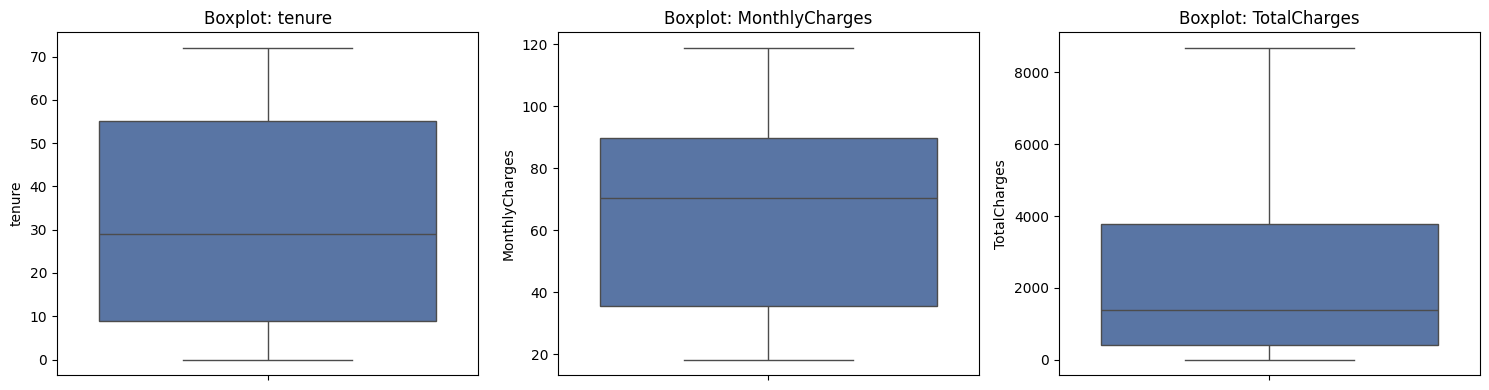

In [12]:
# List of numerical features to assess for potential outliers
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Create side-by-side boxplots for visual outlier detection
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot a boxplot for each numerical feature
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot: {col}")

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

#### 4.4.2 Using the IQR Method

In [13]:
# Quantify outliers in each numerical feature using the IQR method
outlier_counts = []

for col in numerical_cols:
    # Calculate the first quartile (Q1), third quartile (Q3), and IQR
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1

    # Define the lower and upper bounds for outlier detection
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    # Count observations lying outside the IQR bounds
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    # Store the outlier count for each feature
    outlier_counts.append({"Feature": col, "Outlier Count": count})

# Display the outlier summary
pd.DataFrame(outlier_counts)


,Feature,Outlier Count
0,tenure,0
1,MonthlyCharges,0
2,TotalCharges,0


**Conclusion on Outlier Assessment**

The numerical features (tenure, MonthlyCharges, and TotalCharges) were assessed for outliers using the Interquartile Range (IQR) method. The analysis identified no outliers in any of the numerical features, indicating that all observations fall within the expected range of the dataset.

**Decision:** No outlier treatment was required, as no observations were identified outside the IQR bounds. Therefore, all records were retained for subsequent analysis and model development, ensuring that the dataset remained complete while preserving its natural distribution.

### 4.5 Attribute Classification (Nominal / Ordinal / Numeric)

**Purpose:** To classify each feature according to its measurement scale: **Nominal, Ordinal, or Numeric (Discrete/Continuous)**, so that appropriate preprocessing techniques, statistical analyses and machine learning algorithms can be applied.

In [14]:
# Define the conceptual measurement scale of each attribute
attribute_types = {
    "customerID":        "Identifier (dropped, not a feature)",
    "gender":            "Nominal",
    "SeniorCitizen":     "Nominal (binary) -- see note below",
    "Partner":           "Nominal (binary)",
    "Dependents":        "Nominal (binary)",
    "tenure":            "Numeric - Discrete",
    "PhoneService":      "Nominal (binary)",
    "MultipleLines":     "Nominal (3 categories)",
    "InternetService":   "Nominal (3 categories)",
    "OnlineSecurity":    "Nominal (3 categories)",
    "OnlineBackup":      "Nominal (3 categories)",
    "DeviceProtection":  "Nominal (3 categories)",
    "TechSupport":       "Nominal (3 categories)",
    "StreamingTV":       "Nominal (3 categories)",
    "StreamingMovies":   "Nominal (3 categories)",
    "Contract":          "Ordinal -- see note below",
    "PaperlessBilling":  "Nominal (binary)",
    "PaymentMethod":     "Nominal (4 categories)",
    "MonthlyCharges":    "Numeric - Continuous",
    "TotalCharges":      "Numeric - Continuous -- see note below",
    "Churn":             "Nominal (binary) - TARGET",
}

# Display the attribute classification summary
pd.DataFrame(list(attribute_types.items()), columns=["Attribute", "Type"])


,Attribute,Type
0,customerID,"Identifier (dropped, not a feature)"
1,gender,Nominal
2,SeniorCitizen,Nominal (binary) -- see note below
3,Partner,Nominal (binary)
4,Dependents,Nominal (binary)
5,tenure,Numeric - Discrete
6,PhoneService,Nominal (binary)
7,MultipleLines,Nominal (3 categories)
8,InternetService,Nominal (3 categories)
9,OnlineSecurity,Nominal (3 categories)


**Notes on Non-Obvious Attribute Classifications:**

---

1. **`SeniorCitizen`** — Although stored as an integer (`0`/`1`), this feature represents a **binary nominal** variable rather than a quantitative measure. The values simply indicate category membership (senior citizen or not) and do not imply any numerical magnitude or ordering.

2. **`Contract`** — This feature contains the categories **Month-to-month**, **One year**, and **Two year**, which have a natural ordering based on contract duration. It is therefore classified as an **ordinal** variable rather than a nominal categorical variable.

3. **`TotalCharges`** — Although initially stored as an `object` data type due to blank string entries (see Section 4.2), this feature conceptually represents a **continuous numeric** variable. This illustrates the distinction between a feature's **storage data type** and its **true measurement scale**, which do not always coincide.

### 4.6 Encoding Categorical Variables

**Purpose:** To encode categorical variables into numerical representations. Binary and ordinal features are transformed using predefined mappings, while nominal features are designated for one-hot encoding after the train-test split to prevent data leakage.

In [15]:
# Remove the unique customer identifier (not used for modelling)
df_model = df.drop(columns=["customerID"])

# Binary encode Yes/No categorical variables
binary_cols = ["Partner", "Dependents", "PhoneService",
               "PaperlessBilling", "Churn"]

for col in binary_cols:
    df_model[col] = df_model[col].map({"Yes": 1, "No": 0})

# Binary encode gender
df_model["gender"] = df_model["gender"].map({"Male": 1, "Female": 0})

# Ordinal encode Contract using its natural ordering
# (fixed mapping; does not depend on the data and therefore introduces no leakage)
contract_order = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}
df_model["Contract"] = df_model["Contract"].map(contract_order)

# Nominal variables retained for one-hot encoding after the train-test split
nominal_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "PaymentMethod"
]

print("Dataset shape before train-test split:", df_model.shape)
df_model.head()

Dataset shape before train-test split: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,0,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,1,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,0,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,1,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,0,1,Electronic check,70.70,151.65,1


**Justification:**

- Binary categorical variables are encoded as `0` and `1`, preserving all information while producing a numerical representation suitable for machine learning models.

- `Contract` is ordinally encoded rather than one-hot encoded because its categories have a natural ordering based on contract duration. This predefined mapping preserves that ordering and, being specified manually rather than learned from the data, introduces no risk of data leakage.

- The remaining categorical variables are nominal and therefore require one-hot encoding, as no meaningful ordering exists among their categories.
---
To prevent data leakage, one-hot encoding is intentionally performed **after** the train-test split, ensuring that the encoder is fitted only on the training data and then applied unchanged to the test data.

### 4.7 Train/Test Split & Leakage-Free Feature Construction

**Purpose:** To partition the dataset into training and test sets before applying any **data-dependent transformations** (such as one-hot encoding and feature scaling).

This ensures that all preprocessing parameters are learned exclusively from the training data and then applied unchanged to the test data, preventing data leakage and providing an unbiased evaluation of model performance.

In [16]:
# Import the function for splitting the dataset into training and test sets
from sklearn.model_selection import train_test_split

# Import the feature scaling utility (used in the subsequent preprocessing step)
from sklearn.preprocessing import StandardScaler

# Set a fixed random seed to ensure reproducible results
RANDOM_STATE = 42

# Separate the predictor variables (X) and target variable (y)
X_raw = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Identify numerical features that will be standardised later
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Split the dataset into training (80%) and test (20%) sets
# Stratification preserves the original churn distribution in both subsets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# One-hot encode nominal categorical variables in the training set
# The training data defines the feature space used for model development
X_train = pd.get_dummies(
    X_train_raw,
    columns=nominal_cols,
    drop_first=True
)

# Apply the same one-hot encoding procedure to the test set
X_test = pd.get_dummies(
    X_test_raw,
    columns=nominal_cols,
    drop_first=True
)

# Align the test-set columns with the training feature space
# Missing dummy variables are added with a value of 0 to ensure identical input dimensions
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Verify the dimensions of the training and test datasets
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Confirm that both datasets contain the same feature columns
print("\nFeature columns aligned:", list(X_train.columns) == list(X_test.columns))

# Verify that stratified sampling preserved the target class distribution
print("\nTraining churn rate: {:.1f}%".format(y_train.mean() * 100))
print("Test churn rate:     {:.1f}%".format(y_test.mean() * 100))

Training set shape: (5634, 29)
Test set shape: (1409, 29)

Feature columns aligned: True

Training churn rate: 26.5%
Test churn rate:     26.5%


**Observations**

- The dataset was successfully partitioned into **5634 training observations (80%)** and **1409 test observations (20%)**, providing sufficient data for both model training and unbiased performance evaluation.

- The training and test datasets contain **29 identical predictor variables**, confirming that one-hot encoding and column alignment produced a consistent feature space for model development and evaluation.

- Stratified sampling preserved the target class distribution, with a churn rate of **26.5%** in both the training and test sets, ensuring that each subset accurately represents the original dataset.

---

Justification

- An **80:20 train-test split** provides a good balance between maximising the amount of data available for model training while retaining a sufficiently large independent test set for reliable model evaluation.

- **Stratified sampling** was applied to the target variable (`Churn`) because the dataset exhibits a moderate class imbalance (approximately **27% churn**). Without stratification, random sampling could produce training and test sets with different class distributions, leading to biased estimates of model performance. Preserving the class proportions in both subsets ensures a fair and representative evaluation across all classification metrics.

### 4.8 Feature Scaling

**Purpose:** To standardise the continuous numerical features so that they have a common scale, ensuring fair distance calculations for distance-based algorithms such as k-Nearest Neighbours (kNN). The scaler is fitted exclusively on the training data and then applied unchanged to the test data to prevent data leakage.

In [17]:
# Initialise the StandardScaler for feature standardisation
scaler = StandardScaler()

# Create copies of the training and test datasets to preserve the original values
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit the scaler using only the training data and standardise the numerical features
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])

# Apply the same scaling parameters to the test data
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Verify that the scaled numerical features in the training set have means close to zero
print("Scaling complete. Mean of scaled numerical features (training set):\n")
print(X_train_scaled[num_cols].mean().round(3))

Scaling complete. Mean of scaled numerical features (training set):

tenure           -0.0
MonthlyCharges   -0.0
TotalCharges      0.0
dtype: float64


**Observations**

- The continuous numerical features (`tenure`, `MonthlyCharges`, and `TotalCharges`) were successfully standardised using `StandardScaler`.

- The mean of each scaled numerical feature in the **training set** is approximately **0**, confirming that the standardisation process was performed correctly.

- The displayed values of `-0.0` are simply a result of floating-point rounding and are mathematically equivalent to `0.0`.

- The scaler was fitted exclusively on the training data and then applied unchanged to the test data, ensuring that no information from the test set influenced the scaling parameters.

- Only the continuous numerical features were standardised. Binary, ordinal, and one-hot encoded categorical variables were retained in their original numerical representation, as they do not require feature scaling.

**Justification**

- `StandardScaler` was selected to standardise the continuous numerical features (`tenure`, `MonthlyCharges` and `TotalCharges`) because these variables are measured on different scales and do not have a common bounded range.

- Standardisation transforms each feature to have a mean of **0** and a standard deviation of **1**, ensuring that no single feature disproportionately influences distance calculations.

- The scaler was **fitted exclusively on the training data** and then applied unchanged to the test data. This prevents information from the test set from influencing the scaling parameters and eliminates the risk of data leakage.

- Feature scaling is required for **k-Nearest Neighbours (kNN)** because it is a distance-based algorithm whose predictions depend directly on feature magnitudes.

- In contrast, **Decision Trees, Random Forest and AdaBoost** partition the feature space using threshold-based splits rather than distance calculations and are therefore largely unaffected by feature scaling.

- Consequently, the unscaled datasets (`X_train` and `X_test`) are used for the tree-based models, while the scaled datasets (`X_train_scaled` and `X_test_scaled`) are used for the kNN model.

### 4.9 Data Preparation Summary

The following preprocessing steps were completed prior to model development:

- Verified that the dataset contained **no duplicate records**.

- Converted `TotalCharges` from **object** to **numeric**, revealing **11 hidden missing values**.

- Imputed the missing `TotalCharges` values with **0**, based on the business rule that all affected customers had `tenure = 0` and therefore no prior billing history.

- Assessed `tenure`, `MonthlyCharges`, and `TotalCharges` for potential outliers using **boxplots** and the **Interquartile Range (IQR)** method. As all identified observations represented valid customer behaviour, no outlier treatment was applied.

- Classified each feature according to its conceptual measurement scale (Nominal, Ordinal, or Numeric), with justification provided for attributes whose conceptual type differed from their stored data type.

- Encoded categorical variables using **binary encoding**, **ordinal encoding** for `Contract`, and **one-hot encoding** for the remaining nominal variables.

- Partitioned the dataset into **80% training** and **20% test** sets using **stratified sampling** on the target variable (`Churn`) before applying any data-dependent preprocessing, ensuring a leakage-free workflow.

- Standardised the continuous numerical features using `StandardScaler`, fitting the scaler exclusively on the training data and applying the same transformation to the test data.

- Produced the final modelling datasets (`X_train`, `X_test`, `y_train`, `y_test`) together with their scaled counterparts (`X_train_scaled` and `X_test_scaled`), which are used consistently throughout the subsequent modelling and evaluation stages.

## 5. Task B - Decision Tree: Training, Tuning & Evaluation

### 5.1 Baseline Decision Tree

**Purpose:**

- To train a baseline Decision Tree classifier using the default hyperparameters and establish a benchmark for model performance before hyperparameter tuning.

- The baseline model provides a reference for assessing overfitting and the improvements achieved through model optimisation.

In [18]:
# Import the Decision Tree classifier and tree visualisation utilities
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Import evaluation metrics required for model assessment
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

# Initialise the baseline Decision Tree classifier using the default hyperparameters
dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Train the baseline model on the training dataset
dt_baseline.fit(X_train, y_train)

# Compute the training and test accuracy
train_acc = dt_baseline.score(X_train, y_train)
test_acc = dt_baseline.score(X_test, y_test)

# Display the baseline model performance
print(f"Baseline (unconstrained) Decision Tree")
print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy:     {test_acc:.3f}")

# Display the complexity of the trained tree
print(f"Tree Depth: {dt_baseline.get_depth()}")
print(f"Number of Leaf Nodes: {dt_baseline.get_n_leaves()}")

Baseline (unconstrained) Decision Tree
Training Accuracy: 0.998
Test Accuracy:     0.737
Tree Depth: 24
Number of Leaf Nodes: 1088


**Observations**

- The baseline Decision Tree achieved a **training accuracy of 99.8%** but only **73.7% test accuracy**, indicating a substantial gap between training and generalisation performance.

- The trained tree reached a depth of **24** and produced **1088 leaf nodes**, resulting in a highly complex model.

- The near-perfect training accuracy combined with the noticeably lower test accuracy indicates that the model has **overfitted** the training data. Rather than learning the underlying patterns associated with customer churn, the unconstrained tree has also captured dataset-specific noise, reducing its ability to generalise to unseen customers.

- These results establish a baseline for the subsequent hyperparameter tuning stage, where the objective is to reduce model complexity and improve generalisation by controlling the depth of the tree and the minimum number of samples required for node splitting and leaf formation.

**Justification**

- The baseline model was intentionally trained using the default hyperparameters to demonstrate the behaviour of an unconstrained Decision Tree.

- Decision Trees recursively split the training data until no further meaningful partitions can be made, which often results in a very deep and highly complex tree. Although this maximises training accuracy, it also increases the model's variance and susceptibility to overfitting.

- Hyperparameter tuning in the following section focuses on controlling tree complexity through `max_depth`, `min_samples_split`, and `min_samples_leaf`. Restricting these parameters reduces overfitting, improves generalisation to unseen data and achieves a more appropriate balance between bias and variance.

### 5.2 Baseline Model Evaluation

**Purpose:**

- To define a reusable evaluation function that computes the classification metrics required for model assessment, including the **Confusion Matrix**, **Accuracy**, **Precision**, **Recall (Sensitivity)**, **Specificity** and **Negative Predictive Value (NPV)**.

- The function is first applied to the baseline Decision Tree and subsequently reused to evaluate all classification models developed, ensuring a consistent and fair comparison of model performance.

--- Decision Tree (Baseline) ---
Confusion Matrix:
[[852 183]
 [188 186]]

Accuracy:             0.737
Precision:            0.504
Recall (Sensitivity): 0.497
Specificity:          0.823
Negative Predictive Value (NPV): 0.819


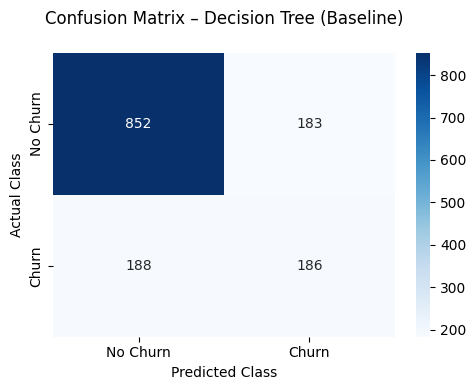

In [19]:
# Define a reusable function to evaluate binary classification models
def evaluate_model(model, X_test, y_test, model_name="Model"):

    # Generate predictions on the test dataset
    y_pred = model.predict(X_test)

    # Compute the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate the required evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)                  # Sensitivity
    specificity = tn / (tn + fp)
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0           # Negative Predictive Value

    # Display the evaluation results
    print(f"--- {model_name} ---")
    print("Confusion Matrix:")
    print(cm)
    print(f"\nAccuracy:             {accuracy:.3f}")
    print(f"Precision:            {precision:.3f}")
    print(f"Recall (Sensitivity): {recall:.3f}")
    print(f"Specificity:          {specificity:.3f}")
    print(f"Negative Predictive Value (NPV): {npv:.3f}")

    # Visualise the confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.title(f"Confusion Matrix – {model_name}\n")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

    # Return the evaluation metrics for later comparison
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "NPV": npv
    }


# Create a dictionary to store evaluation results for all models
results = {}

# Evaluate the baseline Decision Tree model
results["Decision Tree (Baseline)"] = evaluate_model(
    dt_baseline,
    X_test,
    y_test,
    model_name="Decision Tree (Baseline)"
)

**Observations**

- The baseline Decision Tree achieved an **accuracy of 73.7%**, correctly classifying 1038 of the 1409 customers in the test set.

- The confusion matrix shows that **852 non-churning customers (True Negatives)** and **186 churning customers (True Positives)** were correctly classified.

- However, the model incorrectly predicted **183 non-churning customers as churners (False Positives)** and failed to identify **188 actual churners (False Negatives)**.

- The model achieved a **precision of 50.4%**, indicating that only about half of the customers predicted to churn actually churned.

- The **recall (sensitivity) of 49.7%** shows that the model identified only around half of the customers who actually churned, leaving a substantial proportion of churners undetected.

- The **specificity of 82.3%** indicates that the model was considerably better at recognising customers who remained with the company than those who churned.

- The **Negative Predictive Value (NPV) of 81.9%** suggests that customers predicted not to churn were correctly classified in approximately four out of five cases.

**Interpretation**

- The baseline Decision Tree demonstrates **reasonable overall classification performance** but exhibits an imbalance between identifying churners and non-churners.

- While the model performs well in recognising customers who remain with the company (high specificity), its relatively low precision and recall indicate limited effectiveness in detecting customers who are likely to churn.

---
For a customer churn prediction problem, **recall is particularly important**, as failing to identify an at-risk customer (False Negative) represents a missed opportunity for targeted retention efforts. Consequently, improving recall while maintaining acceptable precision becomes a key objective during hyperparameter tuning in the subsequent sections.

### 5.3 Hyperparameter Tuning - Diagnostic Sweeps

**Purpose:**

- To systematically investigate the effect of the key Decision Tree hyperparameters—`max_depth`, `min_samples_split` and `min_samples_leaf` - by varying one parameter at a time while keeping the others at their default values.

- Training and test accuracy are plotted for each parameter setting to visualise the bias–variance trade-off, identify overfitting and underfitting behaviour and determine appropriate ranges for subsequent hyperparameter optimisation.

#### 5.3.1 Effect of max_depth

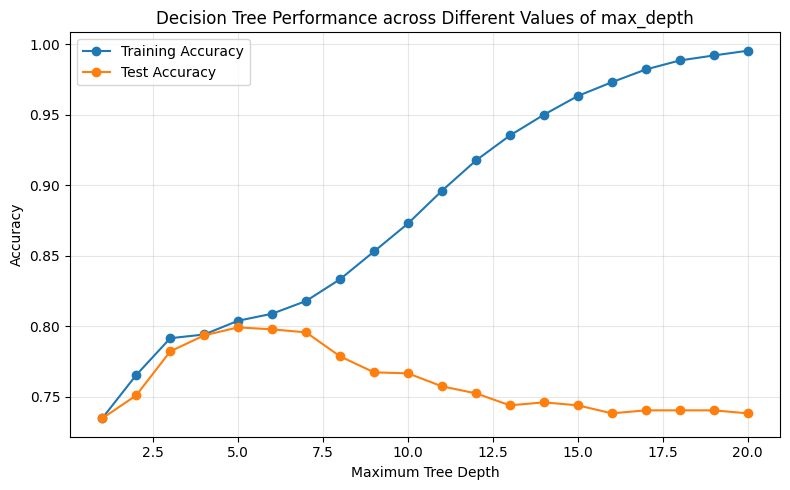

In [20]:
# Evaluate the effect of the maximum tree depth on model performance

# Define the range of candidate tree depths
depths = range(1, 21)

# Store the training and test accuracy for each depth
train_scores = []
test_scores = []

# Train and evaluate a Decision Tree for each maximum depth
for depth in depths:

    clf = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    clf.fit(X_train, y_train)

    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

# Plot the training and test accuracy
plt.figure(figsize=(8,5))

plt.plot(depths, train_scores, marker="o", label="Training Accuracy")
plt.plot(depths, test_scores, marker="o", label="Test Accuracy")

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance across Different Values of max_depth")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 5.3.2 Effect of min_samples_split

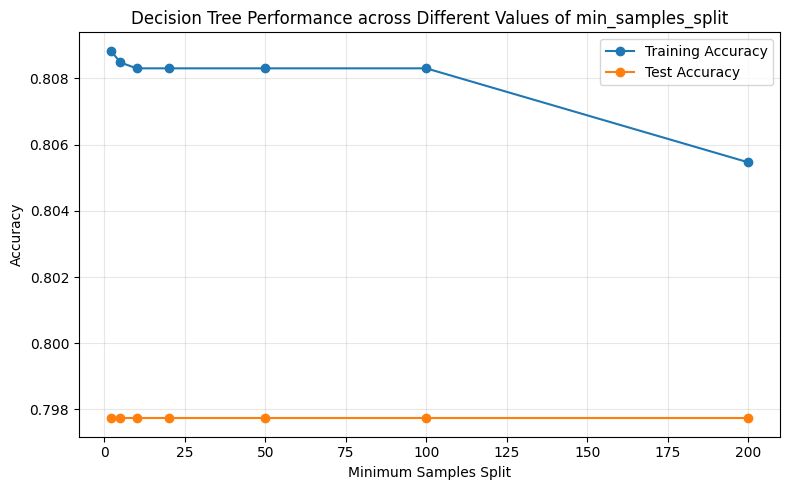

In [21]:
# Evaluate the effect of the minimum number of samples required to split an internal node

# Candidate values for min_samples_split
splits = [2, 5, 10, 20, 50, 100, 200]

train_scores = []
test_scores = []

# Train and evaluate a Decision Tree for each split threshold
for split in splits:

    clf = DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=split,
        random_state=RANDOM_STATE
    )

    clf.fit(X_train, y_train)

    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

# Plot the training and test accuracy
plt.figure(figsize=(8,5))

plt.plot(splits, train_scores, marker="o", label="Training Accuracy")
plt.plot(splits, test_scores, marker="o", label="Test Accuracy")

plt.xlabel("Minimum Samples Split")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance across Different Values of min_samples_split")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 5.3.3 Effect of min_samples_leaf

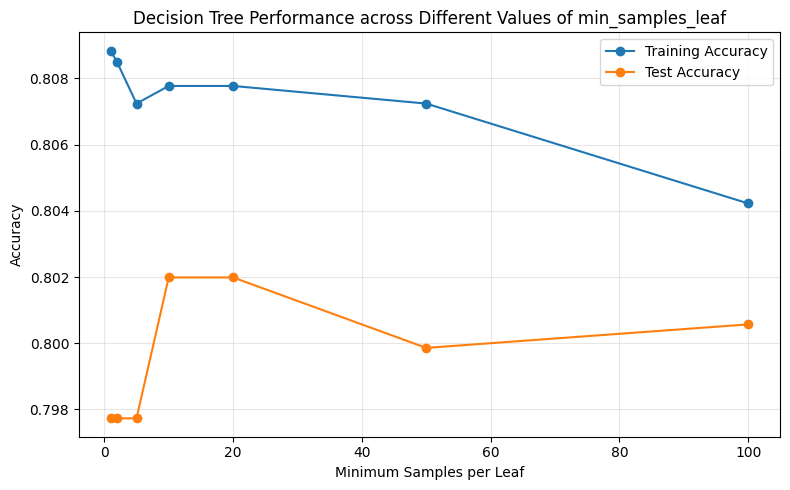

In [22]:
# Evaluate the effect of the minimum number of samples required at each leaf node

# Candidate values for min_samples_leaf
leaves = [1, 2, 5, 10, 20, 50, 100]

train_scores = []
test_scores = []

# Train and evaluate a Decision Tree for each leaf size
for leaf in leaves:

    clf = DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=leaf,
        random_state=RANDOM_STATE
    )

    clf.fit(X_train, y_train)

    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

# Plot the training and test accuracy
plt.figure(figsize=(8,5))

plt.plot(leaves, train_scores, marker="o", label="Training Accuracy")
plt.plot(leaves, test_scores, marker="o", label="Test Accuracy")

plt.xlabel("Minimum Samples per Leaf")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance across Different Values of min_samples_leaf")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observations**

- **Effect of `max_depth`:** Training and test accuracy increase rapidly as the maximum tree depth increases from 1 to approximately **5–6**. Beyond this point, training accuracy continues to rise steadily, eventually approaching **100%**, whereas test accuracy peaks at around **80%** before gradually declining. The widening gap between the two curves clearly indicates increasing **overfitting (high variance)** as the tree becomes more complex.

---

- **Effect of `min_samples_split`:** Increasing `min_samples_split` has only a modest effect on model performance. Both training and test accuracy remain relatively stable across the tested values, suggesting that once an appropriate tree depth is imposed (`max_depth = 6`), the model is comparatively insensitive to this parameter within the selected range.

---

- **Effect of `min_samples_leaf`:** Increasing `min_samples_leaf` from very small values to approximately **10–20** slightly improves test accuracy while reducing training accuracy, indicating improved generalisation through regularisation. Larger leaf sizes continue to simplify the tree, producing a slight reduction in both training and test performance due to increasing bias.

---
- Overall, the diagnostic sweeps demonstrate that **moderate model complexity provides the best generalisation performance**, whereas excessively complex trees achieve higher training accuracy at the expense of poorer performance on unseen data.

**Interpretation**

The diagnostic sweeps clearly illustrate the **bias–variance trade-off** in Decision Tree models.

- **Shallow trees** (small `max_depth`) are unable to capture the underlying relationships within the data, resulting in low training and test accuracy. This behaviour is characteristic of **high bias (underfitting)**.

- As tree complexity increases, both training and test accuracy improve until an optimal level of complexity is reached. Beyond this point, the model continues to improve its fit to the training data while its performance on the test data deteriorates, indicating **high variance (overfitting)**.

- The parameters `min_samples_split` and `min_samples_leaf` act as regularisation mechanisms by restricting unnecessary tree growth. Increasing these values reduces the likelihood of creating decision rules based on a small number of observations, thereby improving the model's ability to generalise.

- Although these diagnostic plots use the **test dataset** to visualise the bias–variance relationship, the test set should **not** be used to select the final hyperparameters, as this would introduce optimistic bias into the reported performance. Consequently, the final hyperparameter selection is performed using **cross-validation on the training data** in the following section, while the test set is reserved exclusively for the final evaluation.

### 5.4 Hyperparameter Selection using Cross-Validation

**Purpose:**

- To select the final Decision Tree hyperparameters using **5-fold cross-validation** on the training dataset.

- The candidate hyperparameter values identified during the diagnostic sweeps are evaluated using cross-validation to estimate their generalisation performance. This ensures that the test dataset remains completely independent and is used only once for the final evaluation of the tuned model.

In [23]:
# Import the classes required for cross-validation and hyperparameter optimisation
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define the cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Define the candidate hyperparameter values
param_grid = {
    "max_depth": [3, 4, 5, 6, 7, 8, 10, 12, None],
    "min_samples_split": [2, 10, 20, 50],
    "min_samples_leaf": [1, 5, 10, 20],
}

# Perform an exhaustive grid search using 5-fold cross-validation
grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# Fit the grid search using only the training dataset
grid_dt.fit(X_train, y_train)

# Display the optimal hyperparameters
print("Best Hyperparameters:")
print(grid_dt.best_params_)

# Display the corresponding mean cross-validation accuracy
print(f"\nMean Cross-Validation Accuracy: {grid_dt.best_score_:.3f}")

Best Hyperparameters:
{'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 50}

Mean Cross-Validation Accuracy: 0.791


**Observations**

- A **5-fold stratified cross-validation** procedure was performed on the training dataset to evaluate all candidate combinations of `max_depth`, `min_samples_split` and `min_samples_leaf`.

- The optimal hyperparameter combination identified through Grid Search was:

  - **Maximum Tree Depth:** 6
  - **Minimum Samples Split:** 50
  - **Minimum Samples Leaf:** 1

- The selected model achieved a **mean cross-validation accuracy of 79.1%**, representing the average predictive performance across the five validation folds.

- The optimal tree depth of **6** is consistent with the diagnostic sweep in Section 5.3, where test accuracy peaked before deeper trees began to overfit. Similarly, a relatively large value of `min_samples_split` (50) indicates that restricting unnecessary node splitting improves the model's ability to generalise.

- Because the hyperparameter search was conducted exclusively on the training dataset, the test dataset remained completely independent and can therefore provide an unbiased estimate of the final model's performance.

**Justification**

Hyperparameter selection was performed using **Grid Search with 5-fold stratified cross-validation**, which evaluates each candidate hyperparameter combination across multiple training–validation splits while preserving the class distribution within every fold. This approach provides a more reliable estimate of model performance than selecting hyperparameters from a single train–test split.

The selected hyperparameters (`max_depth = 6`, `min_samples_split = 50`, and `min_samples_leaf = 1`) represent the configuration that achieved the highest average cross-validation accuracy. Restricting the maximum tree depth and increasing the minimum number of samples required for node splitting reduce model complexity, thereby limiting overfitting while maintaining good predictive performance.

Importantly, the test dataset was excluded from the entire hyperparameter optimisation process. Consequently, it remains an independent benchmark for evaluating the tuned Decision Tree model in the following section, ensuring an unbiased assessment of its generalisation performance.

### 5.5 Final Tuned Decision Tree - Evaluation

**Purpose:**

- To evaluate the final Decision Tree model, configured with the optimal hyperparameters selected through 5-fold cross-validation, on the previously unseen test dataset.

- The evaluation uses the required classification metrics to provide an unbiased estimate of generalisation performance and compares the tuned model with the baseline Decision Tree to assess the impact of hyperparameter optimisation.

--- Decision Tree (Tuned) ---
Confusion Matrix:
[[942  93]
 [192 182]]

Accuracy:             0.798
Precision:            0.662
Recall (Sensitivity): 0.487
Specificity:          0.910
Negative Predictive Value (NPV): 0.831


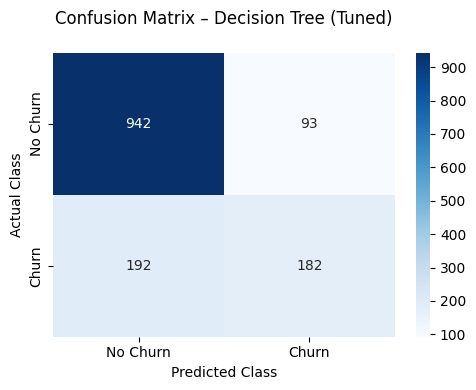

In [24]:
# Create the final Decision Tree using the optimal hyperparameters identified by Grid Search
dt_final = DecisionTreeClassifier(
    **grid_dt.best_params_,
    random_state=RANDOM_STATE
)

# Train the final model on the complete training dataset
dt_final.fit(X_train, y_train)

# Evaluate the tuned model on the previously unseen test dataset
results["Decision Tree (Tuned)"] = evaluate_model(
    dt_final,
    X_test,
    y_test,
    model_name="Decision Tree (Tuned)"
)

In [25]:
# Compare Baseline and Tuned Decision Tree Performance

# Create comparison table
comparison_df = pd.DataFrame({
    "Baseline DT": results["Decision Tree (Baseline)"],
    "Tuned DT": results["Decision Tree (Tuned)"]
})

# Remove the non-metric row
comparison_df = comparison_df.drop(index="Model")

# Convert all metric values to numeric
comparison_df = comparison_df.astype(float)

# Calculate improvement after hyperparameter tuning
comparison_df["Change"] = (
    comparison_df["Tuned DT"] - comparison_df["Baseline DT"]
)

# Round metric values
comparison_df = comparison_df.round(3)

# Format the Change column with +/- sign
comparison_df["Change"] = comparison_df["Change"].apply(lambda x: f"{x:+.3f}")

# Display comparison table
comparison_df.style\
    .set_caption("Table 5.1: Performance Comparison of Baseline and Tuned Decision Tree")\
    .format({
        "Baseline DT": "{:.3f}",
        "Tuned DT": "{:.3f}"
    })\
    .set_properties(**{"text-align": "center"})\
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [("font-size", "14px"),
                                          ("font-weight", "bold")]}
    ])

,Baseline DT,Tuned DT,Change
Accuracy,0.737,0.798,+0.061
Precision,0.504,0.662,+0.158
Recall,0.497,0.487,-0.011
Specificity,0.823,0.910,+0.087
NPV,0.819,0.831,+0.011


**Observations**

- The tuned Decision Tree achieved an **accuracy of 79.8%**, correctly classifying **1124 out of 1409** customers in the test dataset.

- The confusion matrix indicates that the model correctly identified **942 non-churning customers (True Negatives)** and **182 churning customers (True Positives)**, while incorrectly classifying **93 non-churning customers as churners (False Positives)** and **192 churning customers as non-churners (False Negatives)**.

- Compared with the baseline Decision Tree, the tuned model demonstrated improved predictive performance. Test accuracy increased from **73.7% to 79.8%**, while precision improved from **50.4% to 66.2%**, indicating a reduction in false positive predictions.

- The model achieved a **specificity of 91.0%**, showing a strong ability to correctly identify customers who do not churn. The **Negative Predictive Value (NPV) of 83.1%** indicates that customers predicted to remain are classified correctly in most cases.

- The **recall decreased slightly from 49.7% to 48.7%**, indicating that the model continues to identify approximately half of the customers who actually churn. This suggests that the reduction in false positives was accompanied by little improvement in detecting additional churning customers.

---
The tuned Decision Tree outperformed the baseline model, achieving higher accuracy, precision, specificity, and NPV while maintaining a similar level of recall. These results indicate that hyperparameter tuning successfully reduced overfitting and improved the model's ability to generalise to unseen data.

### 5.6 Decision Tree Interpretation

**Purpose:**

- To interpret the final tuned Decision Tree by visualising its structure and examining representative decision paths.

- This analysis explains how the model classifies customers based on feature values, improving the transparency and interpretability of the predictive model.

#### 5.6.1 Visualise Tuned Decision Tree

To improve interpretability, the first few levels of the tuned Decision Tree are exported as text. This representation explicitly shows the sequence of decision rules followed by the model to classify customers as churners or non-churners, making it easier to trace representative prediction paths.

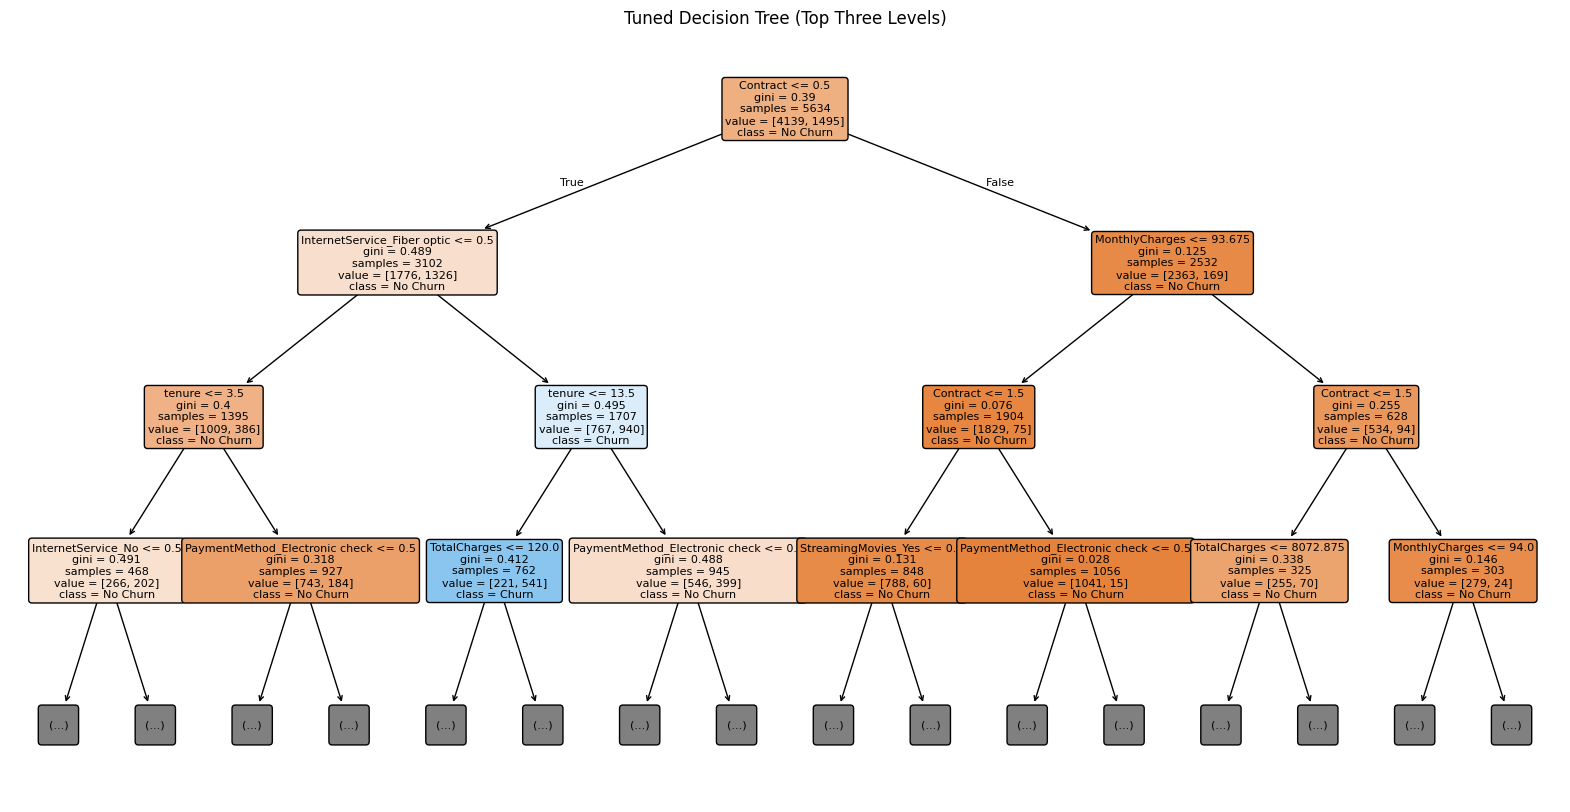

In [26]:
# Visualise the Tuned Decision Tree (Top 3 Levels)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt_final,
    feature_names=X_train.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    max_depth=3,      # Display only the top 3 levels for readability
    fontsize=8
)

plt.title("Tuned Decision Tree (Top Three Levels)")
plt.show()

**Observations**

- The root node splits on **Contract**, indicating that contract type is the most influential predictor of customer churn. This feature provides the greatest reduction in impurity and therefore forms the first decision rule.

- Customers with shorter-term contracts are further separated based on **Internet Service** and **Tenure**, suggesting that service type and customer longevity are important factors for identifying churn risk within this group.

- Customers with longer-term contracts are primarily divided using **Monthly Charges**, followed by **Contract**, **Streaming Movies**, **Payment Method**, and **Total Charges**. These customers generally exhibit a much lower probability of churn.

- The tree uses several business-relevant variables, including **Contract**, **Tenure**, **Monthly Charges**, **Internet Service**, **Payment Method**, **Streaming Movies**, and **Total Charges**, demonstrating that churn decisions are influenced by both customer behaviour and subscription characteristics.

- Most nodes are classified as **No Churn**, reflecting the class imbalance in the training dataset, where non-churning customers constitute the majority class.

- Limiting the visualisation to the only top three levels to improve readability while highlighting the primary decision rules that drive the model's predictions.

#### 5.6.2 Representative Decision Rules

To improve interpretability, the first few levels of the tuned Decision Tree are exported as text. This representation explicitly shows the sequence of decision rules followed by the model to classify customers as churners or non-churners, making it easier to trace representative prediction paths.

In [27]:
# Display Decision Rules (Top 4 Levels)

from sklearn.tree import export_text

print(
    export_text(
        dt_final,
        feature_names=list(X_train.columns),
        max_depth=4
    )
)

|--- Contract <= 0.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- tenure <= 3.50
|   |   |   |--- InternetService_No <= 0.50
|   |   |   |   |--- MonthlyCharges <= 60.20
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- MonthlyCharges >  60.20
|   |   |   |   |   |--- class: 0
|   |   |   |--- InternetService_No >  0.50
|   |   |   |   |--- TotalCharges <= 33.40
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- TotalCharges >  33.40
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- tenure >  3.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- PhoneService <= 0.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- PhoneService >  0.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- tenure <= 22.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- tenure 

**Interpretation of Representative Decision Paths**

The exported decision rules illustrate how the tuned Decision Tree combines multiple customer attributes to classify churn. Two representative paths are summarised below:

---
**Path 1 - Higher Churn Risk**

Customers with a **Month-to-Month Contract**, **Fiber Optic Internet Service**, and **short tenure** are routed towards branches associated with higher churn risk. Additional splits based on **Monthly Charges** and **Total Charges** further refine the prediction, indicating that recently acquired customers with relatively expensive services are more likely to churn.

---
**Path 2 - Lower Churn Risk**

Customers with **long-term contracts (One-Year or Two-Year)** are primarily evaluated using **Monthly Charges**, followed by **Payment Method**, **Senior Citizen**, and **Phone Service**. These branches are predominantly classified as **No Churn**, suggesting that customers with longer contractual commitments generally exhibit higher retention.

**Interpretation**

The exported decision rules confirm that the Decision Tree primarily relies on Contract, Tenure, Internet Service, Monthly Charges, Payment Method and Total Charges to predict customer churn. The hierarchical rule structure demonstrates how multiple customer characteristics are combined to produce transparent and interpretable predictions.

## 6. Task C - Rule-Based Classification

**Purpose:**

- To extract an explicit IF-THEN rule set directly from the tuned Decision Tree, evaluate its predictive performance and discuss the trade-off between interpretability and performance relative to the complete Decision Tree.

### 6.1 Rule Extraction from the Tuned Decision Tree

To extract an explicit set of IF-THEN classification rules from the tuned Decision Tree. Each root-to-leaf path represents a decision rule that can be interpreted independently, providing a transparent description of how the model classifies customers as churners or non-churners.

Decision Trees are inherently rule-based models, where each path from the root node to a leaf node represents a sequence of decision conditions leading to a final prediction.

Rather than manually inspecting the tree, the trained Decision Tree is traversed programmatically to extract all leaf-level decision rules.

Each extracted rule includes its predicted class, the number of training samples reaching that leaf (support), and the proportion of correctly classified samples within the leaf (confidence).

The representative rules with the highest support are then presented for interpretation.

In [28]:
# Import the internal tree structure used to traverse a trained Decision Tree
from sklearn.tree import _tree

# Function to extract all root-to-leaf decision rules from a trained Decision Tree
def tree_to_rules(tree, feature_names, class_names):

    # Access the underlying tree structure
    tree_ = tree.tree_

    # Map feature indices to feature names
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    # Store all extracted rules
    rules = []

    # Recursive function to traverse the tree
    def recurse(node, conditions):

        # Continue traversing if the current node is an internal decision node
        if tree_.feature[node] != _tree.TREE_UNDEFINED:

            name = feature_name[node]
            threshold = tree_.threshold[node]

            # Traverse the left branch (feature <= threshold)
            recurse(
                tree_.children_left[node],
                conditions + [f"{name} <= {threshold:.2f}"]
            )

            # Traverse the right branch (feature > threshold)
            recurse(
                tree_.children_right[node],
                conditions + [f"{name} > {threshold:.2f}"]
            )

        # Leaf node reached: convert the complete path into an IF-THEN rule
        else:

            # Class distribution at the leaf node
            value = tree_.value[node][0]

            # Predicted class for the leaf
            predicted_class = class_names[int(np.argmax(value))]

            # Number of training samples reaching this leaf
            n_samples = int(tree_.n_node_samples[node])

            # Proportion of samples belonging to the predicted class
            confidence = value.max()

            # Store the extracted rule and its associated statistics
            rules.append({
                "rule": " AND ".join(conditions),
                "prediction": predicted_class,
                "support": n_samples,
                "confidence": round(confidence, 3)
            })

    # Start traversing from the root node
    recurse(0, [])

    return rules


# Suppress scientific notation in NumPy output
np.set_printoptions(suppress=True)

# Extract all decision rules from the tuned Decision Tree
rules = tree_to_rules(
    dt_final,
    list(X_train.columns),
    ["No Churn", "Churn"]
)

# Convert extracted rules into a DataFrame and sort by support
rules_df = (
    pd.DataFrame(rules)
      .sort_values("support", ascending=False)
      .reset_index(drop=True)
)

# Display the total number of extracted rules
print(f"Total leaf rules extracted: {len(rules_df)}")

Total leaf rules extracted: 53


**Representative Rules**

In [29]:
# Display the five rules covering the largest number of training samples

for i, row in rules_df.head(5).iterrows():

    print(f"Rule {i+1}: IF {row['rule']}")
    print(
        f"          THEN Predict '{row['prediction']}' "
        f"(support={row['support']}, confidence={row['confidence']})\n"
    )

Rule 1: IF Contract > 0.50 AND MonthlyCharges <= 93.67 AND Contract > 1.50 AND PaymentMethod_Electronic check <= 0.50 AND SeniorCitizen <= 0.50 AND OnlineBackup_Yes <= 0.50
          THEN Predict 'No Churn' (support=624, confidence=0.987)

Rule 2: IF Contract > 0.50 AND MonthlyCharges <= 93.67 AND Contract <= 1.50 AND StreamingMovies_Yes <= 0.50 AND PaymentMethod_Electronic check <= 0.50 AND OnlineBackup_Yes <= 0.50
          THEN Predict 'No Churn' (support=375, confidence=0.979)

Rule 3: IF Contract <= 0.50 AND InternetService_Fiber optic <= 0.50 AND tenure > 3.50 AND PaymentMethod_Electronic check <= 0.50 AND PhoneService > 0.50 AND tenure <= 17.50
          THEN Predict 'No Churn' (support=304, confidence=0.826)

Rule 4: IF Contract > 0.50 AND MonthlyCharges <= 93.67 AND Contract > 1.50 AND PaymentMethod_Electronic check <= 0.50 AND SeniorCitizen <= 0.50 AND OnlineBackup_Yes > 0.50
          THEN Predict 'No Churn' (support=298, confidence=1.0)

Rule 5: IF Contract <= 0.50 AND Inte

**Observations**

- A total of **53** leaf-level decision rules were extracted from the tuned Decision Tree, with each rule representing a unique path from the root node to a terminal leaf.

- The five representative rules correspond to the highest-support leaves, together covering a substantial proportion of the training data and representing the most common customer profiles.

- **Contract** appears in every representative rule, confirming it as the most influential predictor of customer churn. Other frequently occurring attributes include **Monthly Charges**, **Tenure**, **Payment Method**, **Internet Service**, **Online Backup**, and **Total Charges**.

- Four of the five highest-support rules predict **No Churn** with high confidence (82.6% - 100%), reflecting the dominance of retained customers in the training dataset.

- The only representative rule predicting **Churn** is associated with customers having **Month-to-Month contracts**, **Fiber Optic Internet Service** and specific billing characteristics, indicating that churn prediction requires a more specific combination of customer attributes than non-churn prediction.

### 6.2 Rule Set Evaluation

**Purpose**

- To evaluate the predictive performance of the extracted rule set on the unseen test dataset.

- Since the rules are directly derived from the tuned Decision Tree, this evaluation verifies that the extracted rules preserve the model's decision logic.

---
The extracted IF-THEN rules represent the complete set of decision paths in the tuned Decision Tree. Consequently, evaluating the rule set is equivalent to evaluating the tuned Decision Tree itself. The classification metrics obtained in this section therefore confirm that the extracted rules reproduce the predictive behaviour of the original model.

Rule-set (Tree-Derived Rules) Accuracy on Test Set: 0.798
--- Rule-Based (Tree-Derived Rules) ---
Confusion Matrix:
[[942  93]
 [192 182]]

Accuracy:             0.798
Precision:            0.662
Recall (Sensitivity): 0.487
Specificity:          0.910
Negative Predictive Value (NPV): 0.831


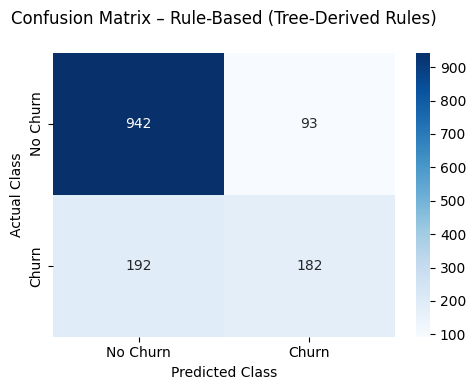

In [30]:
# Evaluate the extracted rule set on the unseen test dataset.
# Since the rules are derived directly from the tuned Decision Tree,
# they preserve exactly the same decision logic and therefore produce
# identical predictions and evaluation metrics.

# Calculate the overall classification accuracy
rule_set_acc = dt_final.score(X_test, y_test)

print(f"Rule-set (Tree-Derived Rules) Accuracy on Test Set: {rule_set_acc:.3f}")

# Evaluate the rule set using the standard classification metrics
results["Rule-Based (Tree-Derived Rules)"] = evaluate_model(
    dt_final,
    X_test,
    y_test,
    "Rule-Based (Tree-Derived Rules)"
)

**Observations**

- The extracted rule set achieved a test accuracy of **79.8%**, correctly classifying **1124 out of 1409** customers.

- The confusion matrix consists of **942 True Negatives**, **182 True Positives**, **93 False Positives**, and **192 False Negatives**, which is identical to the tuned Decision Tree.

- The rule set achieved a **Precision of 66.2%**, **Recall of 48.7%**, **Specificity of 91.0%**, and **Negative Predictive Value (NPV) of 83.1%**, matching the performance of the tuned Decision Tree across all evaluation metrics.

- The identical performance confirms that the extracted IF-THEN rules preserve the decision logic of the tuned Decision Tree without any loss of predictive accuracy.

### 6.3 Interpretability vs. Performance Trade-off

- The extracted rule set provides a transparent representation of the tuned Decision Tree by expressing its decision logic as explicit IF-THEN rules. Individual rules can be easily interpreted and communicated to non-technical stakeholders without requiring visualisation of the complete tree structure. This improves the explainability of the model and supports business decision-making.

- Since the rules are extracted directly from the tuned Decision Tree, they preserve exactly the same decision logic and therefore achieve identical predictive performance. Consequently, no trade-off between interpretability and accuracy is observed in this implementation.

- In practice, a dedicated rule-induction algorithm (e.g., RIPPER) typically learns a smaller and more compact set of rules by approximating the underlying decision boundaries. Such simplification often improves interpretability but may result in a slight reduction in predictive performance. Therefore, the classical interpretability-versus-performance trade-off is generally observed when rule sets are simplified independently rather than extracted directly from an existing Decision Tree.

Overall, the extracted rule set successfully satisfies the objective of providing an interpretable representation of the tuned Decision Tree while preserving identical predictive performance. This demonstrates that Decision Trees can be effectively communicated as explicit IF-THEN rules without sacrificing accuracy when the rules are derived directly from the trained model.

## 7. Task D - kNN (Lazy Learning)

To train and evaluate the k-Nearest Neighbours (kNN) classifier using different values of k, analyse the effect of neighbourhood size on predictive performance, demonstrate the importance of feature scaling for distance-based learning, and examine the bias-variance trade-off associated with different choices of k.

### 7.1 kNN Across k = 1, 3, 5, 7, 9

**Purpose:**

- To train and evaluate the k-Nearest Neighbours (kNN) classifier using the required values of k (1, 3, 5, 7, and 9) on the scaled training dataset and compare their predictive performance on the test dataset.

In [31]:
# Import the k-Nearest Neighbours classifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluate kNN using the required values of k
k_values = [1, 3, 5, 7, 9]
knn_accuracies = []

for k in k_values:

    # Train a kNN classifier using the current value of k
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Evaluate the model on the scaled test dataset
    acc = knn.score(X_test_scaled, y_test)

    # Store the test accuracy for comparison
    knn_accuracies.append(acc)

    print(f"k = {k}: Test Accuracy = {acc:.3f}")


k = 1: Test Accuracy = 0.740
k = 3: Test Accuracy = 0.762
k = 5: Test Accuracy = 0.763
k = 7: Test Accuracy = 0.771
k = 9: Test Accuracy = 0.771


**Observations**

- The kNN classifier was evaluated using the required values of **k = 1, 3, 5, 7, and 9** on the scaled dataset.

- Test accuracy increased from **74%** at **k = 1** to **77.1%** at **k = 7**, indicating that considering more neighbouring observations improved the model's generalisation performance.

- The highest test accuracy of **77.1%** was achieved for both **k = 7** and **k = 9**, suggesting that the model performance stabilised within this range.

- The relatively lower accuracy at **k = 1** indicates that predictions based on a single nearest neighbour are more sensitive to noise and individual training instances.

- Overall, the results suggest that moderate values of **k** provide a better balance between capturing local patterns and reducing prediction variability.

### 7.2 Accuracy (Error Rate) vs. k

**Purpose**

- To compare the classification accuracy and error rate of the kNN classifier across different values of k and identify the neighbourhood size that provides the best predictive performance.

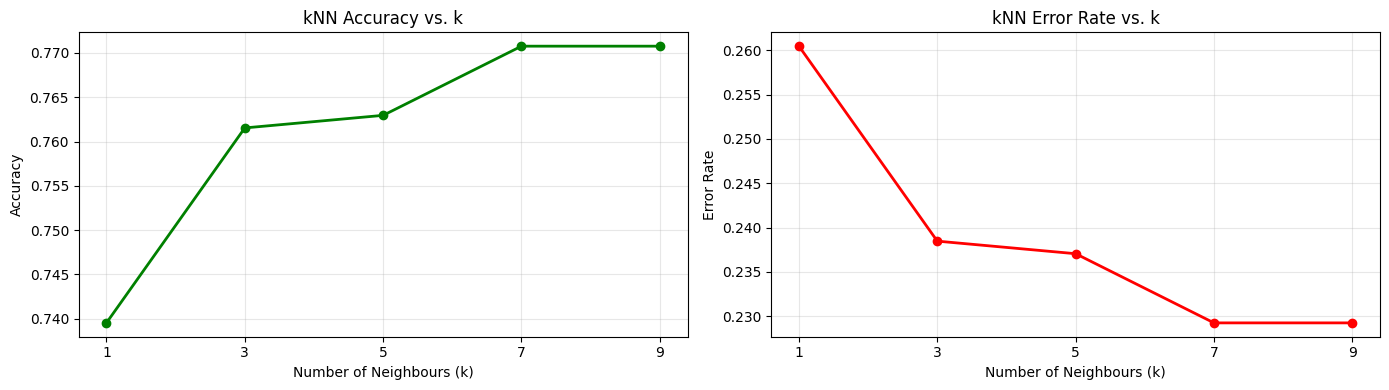

In [32]:
# Calculate the classification error rate
error_rates = [1 - acc for acc in knn_accuracies]

# Create side-by-side plots for Accuracy and Error Rate
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Plot Accuracy against k
ax[0].plot(k_values, knn_accuracies, marker='o', linewidth=2, color='green')
ax[0].set_title("kNN Accuracy vs. k")
ax[0].set_xlabel("Number of Neighbours (k)")
ax[0].set_ylabel("Accuracy")
ax[0].set_xticks(k_values)
ax[0].grid(alpha=0.3)

# Plot Error Rate against k
ax[1].plot(k_values, error_rates, marker='o', linewidth=2, color='red')
ax[1].set_title("kNN Error Rate vs. k")
ax[1].set_xlabel("Number of Neighbours (k)")
ax[1].set_ylabel("Error Rate")
ax[1].set_xticks(k_values)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Note:**

The accuracy and error-rate curves above are plotted using the test set for the required values of k (1, 3, 5, 7, and 9).

While these results illustrate the effect of different neighbourhood sizes, selecting the final value of k based on the test set would introduce test-set leakage.

Therefore, the optimal value of k is determined in the next section using cross-validation on the training set only, ensuring an unbiased final evaluation.

### 7.3 Selection of the Optimal k using Cross-Validation

Although the previous section compared the performance of different values of k on the test set, the test data should not be used for hyperparameter selection because it may lead to optimistic performance estimates.

Instead, cross-validation is performed on the training dataset to identify the value of k that generalises best. The selected value is then used to train the final kNN model, which is evaluated only once on the unseen test dataset.

**Purpose**

- To identify the optimal value of k using cross-validation on the training dataset, thereby selecting the hyperparameter without using the test set and ensuring an unbiased evaluation of the final kNN model.

In [33]:
# Import the function for k-fold cross-validation
from sklearn.model_selection import cross_val_score

# Compute the mean 5-fold cross-validation accuracy for each value of k
cv_scores = {
    k: cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()
    for k in k_values
}

# Display the mean cross-validation accuracy for each k
for k, score in cv_scores.items():
    print(f"k = {k}: Mean 5-fold CV Accuracy = {score:.3f}")

# Select the value of k with the highest mean cross-validation accuracy
best_k = max(cv_scores, key=cv_scores.get)

print(f"\nOptimal k selected using cross-validation: {best_k}")

k = 1: Mean 5-fold CV Accuracy = 0.716
k = 3: Mean 5-fold CV Accuracy = 0.751
k = 5: Mean 5-fold CV Accuracy = 0.768
k = 7: Mean 5-fold CV Accuracy = 0.778
k = 9: Mean 5-fold CV Accuracy = 0.782

Optimal k selected using cross-validation: 9


--- kNN (k=9, scaled) ---
Confusion Matrix:
[[874 161]
 [162 212]]

Accuracy:             0.771
Precision:            0.568
Recall (Sensitivity): 0.567
Specificity:          0.844
Negative Predictive Value (NPV): 0.844


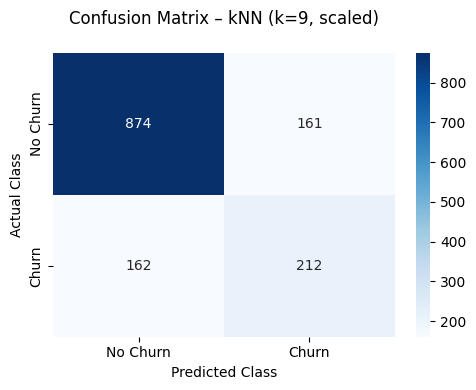

In [34]:
# Train the final kNN model using the optimal value of k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

# Evaluate the final model on the unseen test dataset
results[f"kNN (k={best_k}, scaled)"] = evaluate_model(
    knn_best,
    X_test_scaled,
    y_test,
    f"kNN (k={best_k}, scaled)"
)

**Observations**

- The final kNN model (k = 9) achieved a test accuracy of 77.1%, correctly classifying 1086 of 1,409 customer records.

- The confusion matrix shows that the model correctly identified 874 customers who did not churn and 212 customers who churned.

- The model produced 161 false positives and 162 false negatives, indicating a balanced distribution of misclassification errors between the two classes.

- The precision (56.8%) and recall (56.7%) are nearly identical, suggesting that the model maintains a balanced ability to identify churning customers while limiting incorrect churn predictions.

- The relatively high specificity (84.4%) indicates that the model is more effective at identifying customers who remain with the company than those who churn.

---
Overall, the cross-validation process selected an appropriate value of k, and the final model demonstrated stable performance on the unseen test dataset.

### 7.4 Empirical Proof: Why Scaling Matters for kNN

**Purpose:**

- To empirically compare the performance of the kNN classifier with and without feature scaling using the same value of k, thereby demonstrating the importance of feature scaling for distance-based learning.

The k-Nearest Neighbours algorithm classifies observations based on the distance between feature vectors.

When predictor variables have different numerical scales, features with larger magnitudes can dominate the distance calculation, reducing the influence of other variables.

Feature scaling standardises the predictor variables so that each contributes proportionately to the distance metric.

In [35]:
# Train a kNN model on the original (unscaled) features
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k)
knn_unscaled.fit(X_train, y_train)

# Compute test accuracy for the scaled and unscaled models
acc_unscaled = knn_unscaled.score(X_test, y_test)
acc_scaled = knn_best.score(X_test_scaled, y_test)

# Compare the effect of feature scaling
print(f"kNN (k={best_k}) Accuracy WITH Scaling:    {acc_scaled:.3f}")
print(f"kNN (k={best_k}) Accuracy WITHOUT Scaling: {acc_unscaled:.3f}")
print(f"Accuracy Difference: {acc_scaled - acc_unscaled:.3f}")

kNN (k=9) Accuracy WITH Scaling:    0.771
kNN (k=9) Accuracy WITHOUT Scaling: 0.788
Accuracy Difference: -0.017


**Why Feature Scaling is Important for kNN**

* The **k-Nearest Neighbours (kNN)** algorithm classifies observations based on the **Euclidean distance** between feature vectors.

* In the Telco Customer Churn dataset, **`TotalCharges`** ranges up to approximately **8,000**, **`tenure`** ranges from **0–72**, whereas most one-hot encoded and binary features take values only **0 or 1**.

* Without feature scaling, variables with larger numerical ranges contribute disproportionately to the distance calculation and may dominate the neighbourhood selection, reducing the influence of features measured on smaller scales.

* In contrast, **Decision Trees** and tree-based ensemble methods are not affected by feature scale because they partition the data using threshold-based splits on individual features rather than distance calculations.

---

**Empirical Observation**

* In this experiment, the difference between the scaled and unscaled kNN models was relatively small (**78.8% vs. 77.1%**, a difference of **1.7 percentage points**).

* This modest difference is likely because the dataset contains a large number of **binary and one-hot encoded features**, while only a few variables (`tenure`, `MonthlyCharges`, and `TotalCharges`) have substantially different numerical scales.

* Consequently, although feature scaling changes the distance calculations, its overall impact is moderated by the large proportion of features that are already measured on comparable scales.

* This demonstrates that **feature scaling influences the behaviour of kNN**, but the magnitude and direction of its effect depend on the characteristics and feature distributions of the dataset.

### 7.5 Bias-Variance Trade-off as k Increases

**Purpose**

- To explain how the choice of k influences the bias-variance trade-off in the k-Nearest Neighbours algorithm and relate this behaviour to the experimental findings.

The value of k controls the complexity of the kNN classifier. Choosing an appropriate neighbourhood size is important because it determines the balance between fitting the training data closely and generalising well to unseen observations.


---
- At **k = 1**, each prediction is determined by the single nearest neighbour. This produces a highly flexible decision boundary with **low bias but high variance**, making the model sensitive to noise and individual training samples.

- As k increases, predictions are based on the majority vote of a larger neighbourhood. This smooths the decision boundary, resulting in **higher bias but lower variance**, and generally improves the model's ability to generalise.

- If k becomes excessively large relative to the dataset size, the model may underfit because local patterns are oversmoothed. For the Telco Customer Churn dataset, where approximately 27% of customers belong to the churn class, a very large value of k could bias predictions towards the majority "No Churn" class, reducing the model's ability to identify customers who churn.

**Relation to Experimental Results**

- Test accuracy increased from 74.0% at k = 1 to 77.1% at k = 7 and k = 9, indicating that increasing the neighbourhood size reduced model variance and improved generalisation.

- Five-fold cross-validation identified k = 9 as the optimal value, suggesting that it achieved the most appropriate balance between bias and variance for this dataset.

These findings shows that selecting k involves balancing model complexity against predictive stability, making cross-validation an effective approach for choosing the optimal neighbourhood size.

---
**Key Takeaway**

The value of k directly controls the bias–variance trade-off in kNN. Small values of k produce complex models that are more prone to overfitting, whereas excessively large values may oversimplify the decision boundary and underfit the data. Cross-validation helps identify a value of k that balances these competing effects and provides robust predictive performance on unseen data.

## 8. Task E - Ensemble Learning

**Purpose**

- To develop and evaluate two ensemble learning methods- Random Forest and AdaBoost, for customer churn prediction.

- Each model is first trained using default hyperparameters and then optimised using five-fold cross-validation on the training dataset.

- The final tuned models are evaluated on the unseen test dataset and compared with the Decision Tree and k-Nearest Neighbours models to assess their predictive performance, robustness and generalisation.

- To examine why ensemble methods typically outperform a single Decision Tree and explains how Random Forest (bagging) and AdaBoost (boosting) address the bias-variance trade-off using different learning strategies.

In [36]:
# Imports for Ensemble Learning
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

### 8.1 Random Forest (Bagging)

Random Forest is an ensemble learning algorithm based on the bagging (Bootstrap Aggregating) technique. Instead of building a single Decision Tree, it constructs multiple Decision Trees using different bootstrap samples of the training data. At each split, only a random subset of predictor variables is considered, increasing diversity among the trees. The final prediction is obtained through majority voting across all trees, which reduces model variance and generally improves predictive performance and robustness compared with a single Decision Tree.

**Purpose**

- To train and evaluate a Random Forest classifier for customer churn prediction.

- The model is initially trained using default hyperparameters to establish a baseline, followed by hyperparameter tuning using five-fold cross-validation. The final tuned model is then evaluated on the unseen test dataset.

#### 8.1.1 Baseline Random Forest


A baseline model provides a reference point for evaluating whether hyperparameter tuning leads to meaningful improvements in predictive performance.

- To train a baseline Random Forest classifier using the default hyperparameters provided by scikit-learn and establish a benchmark before hyperparameter tuning.

--- Random Forest (Baseline) ---
Confusion Matrix:
[[926 109]
 [190 184]]

Accuracy:             0.788
Precision:            0.628
Recall (Sensitivity): 0.492
Specificity:          0.895
Negative Predictive Value (NPV): 0.830


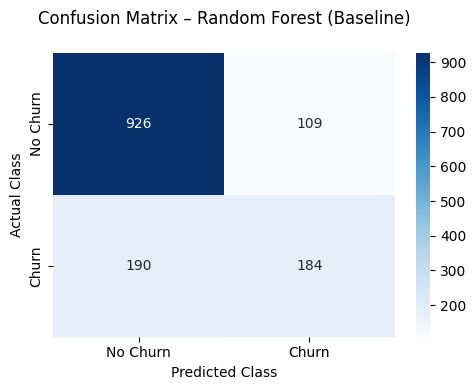

In [37]:
# Train a baseline Random Forest classifier
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE)

rf_baseline.fit(X_train, y_train)

# Evaluate the baseline model on the test dataset
results["Random Forest (Baseline)"] = evaluate_model(
    rf_baseline,
    X_test,
    y_test,
    "Random Forest (Baseline)"
)

**Observations**

- The baseline Random Forest achieved an **accuracy of 78.8%** on the test dataset.

- The model correctly classified 1110 of 1409 customers.

- It identified 184 churning customers while correctly recognising 926 non-churning customers.

- The model achieved a **precision of 62.8%**, indicating that nearly two-thirds of customers predicted to churn actually churned.

- The **recall of 49.2%** shows that approximately half of the actual churning customers were successfully detected.

- A **specificity of 89.5%** demonstrates strong performance in correctly identifying customers who did not churn.

#### 8.1.2 Hyperparameter Tuning using Cross-Validation


Although the baseline Random Forest often performs well using default settings, its predictive performance can be further improved by selecting appropriate hyperparameters.

**Purpose**

- To identify the optimal Random Forest hyperparameters using five-fold cross-validation on the training dataset and obtain a tuned model with improved generalisation performance.
---

- **GridSearchCV** with five-fold cross-validation was used to evaluate different combinations of the number of trees (n_estimators), maximum tree depth (max_depth), and the number of features considered at each split (max_features).

- The combination achieving the highest mean validation accuracy was selected as the final model.

In [38]:
# Define the Random Forest hyperparameter search space
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "max_features": ["sqrt", "log2"],
}

# Perform 5-fold cross-validation
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

# Retrieve the best-performing model
best_rf = grid_rf.best_estimator_

# Display the optimal hyperparameters
print("Best Random Forest Parameters:", grid_rf.best_params_)
print(f"Mean CV Accuracy: {grid_rf.best_score_:.3f}")

Best Random Forest Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
Mean CV Accuracy: 0.805


**Observations**

- Five-fold cross-validation evaluated multiple Random Forest configurations to identify the optimal hyperparameter combination.

- The **highest mean cross-validation accuracy of 80.5%** was achieved using 100 decision trees, a maximum tree depth of 10, and considering the square root of the available features at each split.

- Limiting the maximum tree depth to 10 suggests that moderately deep trees provide better generalisation than fully grown trees for this dataset.

- Selecting 100 trees indicates that increasing the ensemble beyond this size did not provide a meaningful improvement within the evaluated search space.

---
The tuned Random Forest model obtained through cross-validation is evaluated on the unseen test dataset in the next section to assess its predictive performance and generalisation capability.

#### 8.1.3 Final Random Forest Evaluation

**Purpose**

- To evaluate the predictive performance of the tuned Random Forest classifier on the unseen test dataset and assess its ability to correctly identify customers who are likely to churn.

--- Random Forest (Tuned) ---
Confusion Matrix:
[[938  97]
 [180 194]]

Accuracy:             0.803
Precision:            0.667
Recall (Sensitivity): 0.519
Specificity:          0.906
Negative Predictive Value (NPV): 0.839


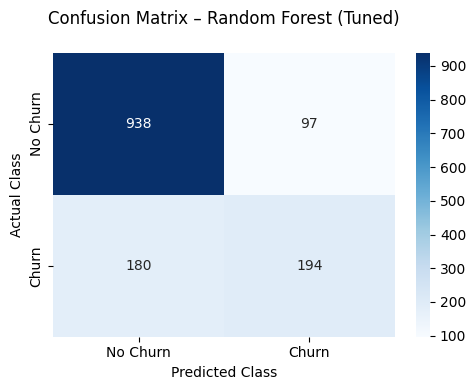

In [39]:
# Evaluate the tuned Random Forest model on the unseen test dataset
results["Random Forest (Tuned)"] = evaluate_model(
    best_rf,
    X_test,
    y_test,
    "Random Forest (Tuned)"
)

**Observations**

- The tuned Random Forest model achieved an overall **accuracy of 80.3%**, correctly classifying 1132 of the 1409 customers in the test dataset.
The model correctly identified 194 customers who churned and 938 customers who did not churn.

- The **precision of 66.7%** indicates that approximately two-thirds of customers predicted to churn actually churned.

- The **recall of 51.9%** shows that the model successfully identified just over half of the customers who eventually churned.

- The model achieved a **specificity of 90.6%**, demonstrating strong performance in correctly recognising customers who were unlikely to churn.

- The **NPV of 83.9%** indicates that customers predicted to remain were correctly classified in most cases.

**Interpretation**

Hyperparameter tuning improved the Random Forest model compared with the baseline model.

Test accuracy increased from 78.8% to 80.3%, while precision improved from 62.8% to 66.7%, resulting in fewer false churn predictions. Recall also increased from 49.2% to 51.9%, enabling the model to identify more customers at risk of churning.

Also, specificity improved from 89.5% to 90.6%, indicating better identification of customers who were unlikely to churn.

#### 8.1.4 Feature Importance Analysis

**Purpose**

- To identify which features the tuned Random Forest relies on most heavily when predicting churn, and to check whether these agree with the split variables chosen independently by the Decision Tree (Section 5.6.1).

---
Agreement between two different model families on the same top drivers is stronger evidence than either model's result alone.

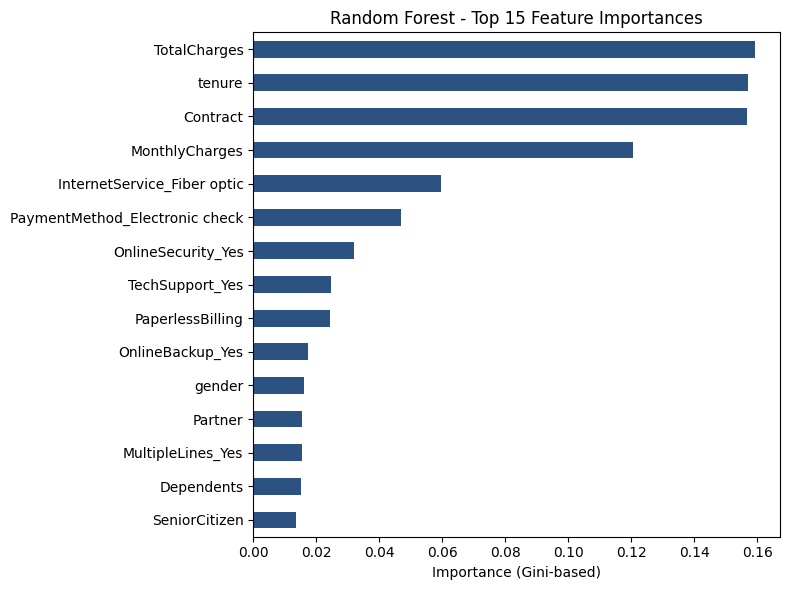

TotalCharges                      0.159270
tenure                            0.157135
Contract                          0.156781
MonthlyCharges                    0.120648
InternetService_Fiber optic       0.059689
PaymentMethod_Electronic check    0.047045
OnlineSecurity_Yes                0.032042
TechSupport_Yes                   0.024592
PaperlessBilling                  0.024508
OnlineBackup_Yes                  0.017270
gender                            0.016041
Partner                           0.015563
MultipleLines_Yes                 0.015399
Dependents                        0.015092
SeniorCitizen                     0.013523
dtype: float64


In [40]:
# Extract feature importances from the tuned Random Forest
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_importances = importances.sort_values(ascending=False).head(15)

# Plot the top 15 most important features
plt.figure(figsize=(8, 6))
top_importances.sort_values().plot(kind="barh", color="#2c5282")
plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance (Gini-based)")
plt.tight_layout()
plt.show()

# Display the exact values for reference in the report
print(top_importances)

**Observations**

- Four features dominate the model: **TotalCharges (0.159)**, **tenure (0.157)**, **Contract (0.157)** and **MonthlyCharges (0.121)** together account for roughly **59%** of total importance, with a sharp drop-off after that.

- **InternetService_Fiber optic (0.060)** and **PaymentMethod_Electronic check (0.047)** form a clear second tier, followed by a long tail of service-related flags (`OnlineSecurity_Yes`, `TechSupport_Yes`, `PaperlessBilling`, `OnlineBackup_Yes`) each contributing only 0.02 - 0.03.

- Demographic features like `gender` (0.016), `Partner` (0.016), `Dependents` (0.015), `SeniorCitizen` (0.014)-  sit at the bottom of the ranking, suggesting the model relies primarily on **billing and contractual behaviour rather than customer demographics** to predict churn.

- This strongly agrees with the tuned Decision Tree (Section 5.6.1): its root split was on `Contract`, followed immediately by `InternetService_Fiber optic`, `tenure`, and `MonthlyCharges` in the next two levels.

- Two structurally different models- a single interpretable tree and a 100-tree ensemble, independently converge on the same four to five variables as the dominant churn signal, which is stronger evidence than either model's ranking alone.

---

**NOTE:** `TotalCharges` is actually a product of `tenure x  MonthlyCharges`, so its top ranking is partly correlated with (not fully independent of) the other two - the three together should be read as one strong "billing history" signal rather than three fully separate drivers.

### 8.2 AdaBoost (Boosting)

AdaBoost (Adaptive Boosting) is a boosting-based ensemble learning algorithm. Unlike Random Forest, which builds multiple Decision Trees independently, AdaBoost constructs a sequence of weak learners, where each successive model focuses more on the instances that were misclassified by previous learners. By combining the weighted predictions of these learners, AdaBoost aims to improve overall predictive performance. This sequential learning process often produces a model with lower bias while maintaining good generalisation on unseen data.

#### 8.2.1 Baseline AdaBoost

A baseline model provides a reference point for assessing whether hyperparameter tuning improves predictive performance.

**Purpose**

- To train a baseline AdaBoost classifier using the default hyperparameters provided by scikit-learn and establish a benchmark before hyperparameter tuning.

--- AdaBoost (Baseline) ---
Confusion Matrix:
[[916 119]
 [180 194]]

Accuracy:             0.788
Precision:            0.620
Recall (Sensitivity): 0.519
Specificity:          0.885
Negative Predictive Value (NPV): 0.836


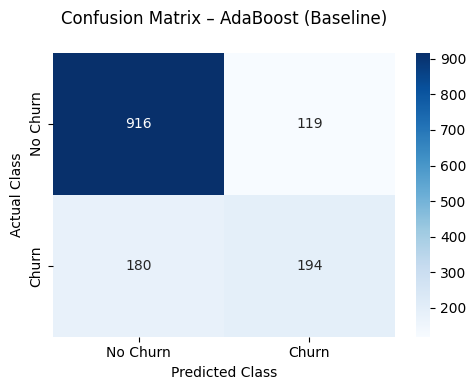

In [41]:
# Train a baseline AdaBoost classifier
ada_baseline = AdaBoostClassifier(random_state=RANDOM_STATE)

ada_baseline.fit(X_train, y_train)

# Evaluate the baseline model on the test dataset
results["AdaBoost (Baseline)"] = evaluate_model(
    ada_baseline,
    X_test,
    y_test,
    "AdaBoost (Baseline)"
)

**Observations**

- The baseline AdaBoost model achieved an **accuracy of 78.8%** on the test dataset.

- The model correctly classified 1110 of 1409 customers.

- It correctly identified 194 customers who churned while accurately classifying 916 customers who did not churn.

- The model achieved a **precision of 62%**, indicating that approximately three out of five customers predicted to churn actually churned.

- The **recall of 51.9%** shows that just over half of the actual churners were successfully identified.

- A **specificity of 88.5%** demonstrates strong performance in correctly identifying customers who remained with the company.

---

The baseline AdaBoost model achieved the same overall accuracy as the baseline Random Forest (78.8%), while providing a slightly higher recall (51.9% vs. 49.2%) at the expense of a small reduction in precision and specificity. This indicates a slightly better ability to identify customers who are likely to churn, although some additional non-churning customers are incorrectly classified as churners. Hyperparameter tuning is performed next to determine whether AdaBoost can further improve its predictive performance and generalisation on unseen data.

#### 8.2.2 Hyperparameter Tuning using Cross-Validation

The predictive performance of AdaBoost depends on hyperparameters that control the size of the ensemble and the contribution of each weak learner.

**Purpose**

- To identify the optimal AdaBoost hyperparameters using five-fold cross-validation on the training dataset and select the model configuration that provides the best generalisation performance.

---
- **GridSearchCV** with five-fold cross-validation was used to evaluate different combinations of the number of estimators (n_estimators) and the learning rate (learning_rate).

- The hyperparameter combination achieving the highest mean cross-validation accuracy was selected as the final AdaBoost model.

In [42]:
# Define the AdaBoost hyperparameter search space
ada_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.1, 0.5, 1.0],
}

# Perform 5-fold cross-validation
grid_ada = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=RANDOM_STATE),
    param_grid=ada_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

# Retrieve the best-performing AdaBoost model
best_ada = grid_ada.best_estimator_

# Display the optimal hyperparameters and validation performance
print("Best AdaBoost Parameters:", grid_ada.best_params_)
print(f"Mean CV Accuracy: {grid_ada.best_score_:.3f}")

Best AdaBoost Parameters: {'learning_rate': 0.5, 'n_estimators': 200}
Mean CV Accuracy: 0.803


**Observations**

- Five-fold cross-validation was used to evaluate different combinations of the number of estimators and learning rate.

- The highest mean cross-validation accuracy of 80.3% was achieved using 200 estimators with a learning rate of 0.5.

- The selected configuration indicates that a larger ensemble of weak learners combined with a moderate learning rate provided the best generalisation performance among the evaluated models.

- Increasing the number of estimators beyond the default value allowed AdaBoost to improve its learning capacity, while a learning rate of 0.5 balanced the contribution of each learner without overly aggressive updates.

---
The tuned AdaBoost model obtained through cross-validation is evaluated on the unseen test dataset in the next section to assess its predictive performance and compare it with the other classification models.

#### 8.2.3 Final AdaBoost Evaluation

**Purpose**

- To evaluate the predictive performance of the tuned AdaBoost classifier on the unseen test dataset and assess its ability to correctly identify customers who are likely to churn.

--- AdaBoost (Tuned) ---
Confusion Matrix:
[[923 112]
 [179 195]]

Accuracy:             0.793
Precision:            0.635
Recall (Sensitivity): 0.521
Specificity:          0.892
Negative Predictive Value (NPV): 0.838


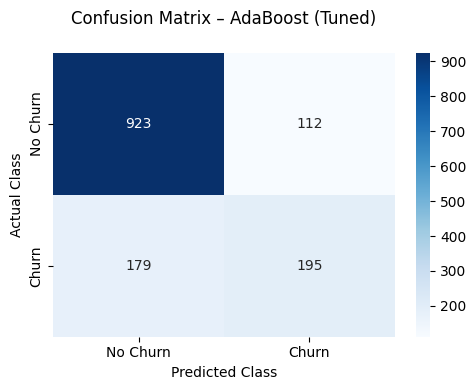

In [43]:
# Evaluate the tuned AdaBoost model on the unseen test dataset
results["AdaBoost (Tuned)"] = evaluate_model(
    best_ada,
    X_test,
    y_test,
    "AdaBoost (Tuned)"
)

**Observations**

- The tuned AdaBoost model achieved an overall **accuracy of 79.3%**, correctly classifying 1118 of the 1409 customers in the test dataset.

- The model correctly identified 195 customers who churned while correctly classifying 923 customers who did not churn.

- The model achieved a **precision of 63.5%**, indicating that nearly two-thirds of customers predicted to churn actually churned.

- The **recall improved to 52.1%**, allowing the model to identify more actual churners than the baseline AdaBoost model.

- A **specificity of 89.2%** demonstrates that the model continued to perform well in recognising customers who were unlikely to churn.

- The **NPV of 83.8%** indicates that customers predicted to remain were correctly classified in most cases.

**Interpretation**

Hyperparameter tuning resulted in a modest improvement over the baseline AdaBoost model.

Test accuracy increased from 78.8% to 79.3%, while recall improved from 51.9% to 52.1%, enabling the model to identify slightly more customers at risk of churning.

Precision also increased from 62.0% to 63.5%, indicating fewer false churn predictions, while specificity remained high at 89.2%.

---
Overall, the tuned AdaBoost model demonstrated slightly better generalisation performance than the baseline model and provided a balanced trade-off between detecting churners and limiting false positive predictions.

### 8.3 Why Ensembles Typically Outperform a Single Decision Tree

A single Decision Tree, particularly a deep tree, is prone to high variance, meaning that small changes in the training data can produce substantially different tree structures and predictions. Ensemble methods improve model performance by combining multiple learners, thereby reducing prediction errors through different mechanisms.

---
**Random Forest (Bagging):**

Random Forest constructs multiple Decision Trees using different bootstrap samples of the training data and random subsets of features at each split. The final prediction is obtained through majority voting across all trees. By averaging the predictions of multiple de-correlated trees, Random Forest effectively **reduces model variance**, resulting in better generalisation and improved robustness to overfitting.

**AdaBoost (Boosting):**

AdaBoost builds an ensemble of weak learners sequentially, where each new learner focuses more on the instances that were misclassified by previous learners. The final prediction is obtained through a weighted combination of all learners. This sequential learning process primarily **reduces model bias**, enabling the ensemble to capture more complex decision boundaries than an individual weak learner.

---
Overall, ensemble methods improved predictive performance by addressing the limitations of individual Decision Trees through complementary learning strategies.

**Bagging primarily reduces variance by averaging multiple strong learners, whereas boosting primarily reduces bias by combining multiple weak learners into a stronger classifier**.

Both ensemble methods achieved better overall performance than a single Decision Tree, with the tuned **Random Forest producing the highest classification accuracy** among the evaluated models.

## 9. Task F - Final Comparison & Recommendation

### 9.1 Model Comparison Table

To compare the predictive performance of all classification models using a common set of evaluation metrics and summarise their key characteristics.

In [44]:
# Model Comparison Table

# Create comparison DataFrame from stored evaluation results
comparison_df = pd.DataFrame(results.values())

# Select evaluation metrics
comparison_df = comparison_df[
    ["Model", "Accuracy", "Precision", "Recall", "Specificity"]
]

# Add concise model summaries
comparison_df["Notes"] = [
    "High variance; severe overfitting",
    "Reduced variance through hyperparameter tuning",
    "Same predictive performance; highly interpretable",
    "Distance-based learner; selected using cross-validation",
    "Baseline Random Forest model",
    "Best overall performance; bagging reduces variance",
    "Baseline AdaBoost model",
    "Sequential boosting reduces bias"
]

# Arrange models in logical order
model_order = [
    "Decision Tree (Baseline)",
    "Decision Tree (Tuned)",
    "Rule-Based (Tree-Derived Rules)",
    "kNN (k=9, scaled)",
    "Random Forest (Baseline)",
    "Random Forest (Tuned)",
    "AdaBoost (Baseline)",
    "AdaBoost (Tuned)"
]

comparison_df["Model"] = pd.Categorical(
    comparison_df["Model"],
    categories=model_order,
    ordered=True
)

comparison_df = (
    comparison_df
    .sort_values("Model")
    .reset_index(drop=True)
)

# Display formatted comparison table
comparison_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "Specificity": "{:.3f}"
}).highlight_max(
    subset=["Accuracy", "Precision", "Recall", "Specificity"],
    color="#D8F3DC"
)

,Model,Accuracy,Precision,Recall,Specificity,Notes
0,Decision Tree (Baseline),0.737,0.504,0.497,0.823,High variance; severe overfitting
1,Decision Tree (Tuned),0.798,0.662,0.487,0.910,Reduced variance through hyperparameter tuning
2,Rule-Based (Tree-Derived Rules),0.798,0.662,0.487,0.910,Same predictive performance; highly interpretable
3,"kNN (k=9, scaled)",0.771,0.568,0.567,0.844,Distance-based learner; selected using cross-validation
4,Random Forest (Baseline),0.788,0.628,0.492,0.895,Baseline Random Forest model
5,Random Forest (Tuned),0.803,0.667,0.519,0.906,Best overall performance; bagging reduces variance
6,AdaBoost (Baseline),0.788,0.620,0.519,0.885,Baseline AdaBoost model
7,AdaBoost (Tuned),0.793,0.635,0.521,0.892,Sequential boosting reduces bias


**Observations**

* The **tuned Random Forest** achieved the highest **Accuracy (0.803)** and **Precision (0.667)** among all evaluated models, indicating the strongest overall predictive performance.

* The **kNN (k = 9)** classifier achieved the highest **Recall (0.567)**, demonstrating the greatest ability to correctly identify customers who eventually churned.

* The **tuned Decision Tree** and the **Rule-Based classifier** achieved the highest **Specificity (0.910)**, correctly identifying the largest proportion of non-churning customers.

* Hyperparameter tuning improved the performance of both **Decision Tree** and **Random Forest**, demonstrating the effectiveness of controlling model complexity and reducing overfitting.

* The **Rule-Based classifier** achieved identical predictive performance to the tuned Decision Tree while offering greater interpretability through explicit IF-THEN decision rules.

* Overall, the **ensemble methods (Random Forest and AdaBoost)** demonstrated better generalisation performance than the baseline Decision Tree, with the **tuned Random Forest** providing the best balance between predictive accuracy, precision, recall and specificity for this customer churn prediction task.


#### 9.1.1 ROC Curve & AUC Comparison

**Purpose**

Accuracy, precision and recall are all computed at a single default decision threshold (0.5). The ROC curve instead shows each model's true-positive vs. false-positive rate across **every possible threshold**, and the AUC (Area Under the Curve) summarises overall ranking ability in one number, useful for judging which model separates churners from non-churners best, independent of where the threshold is set.

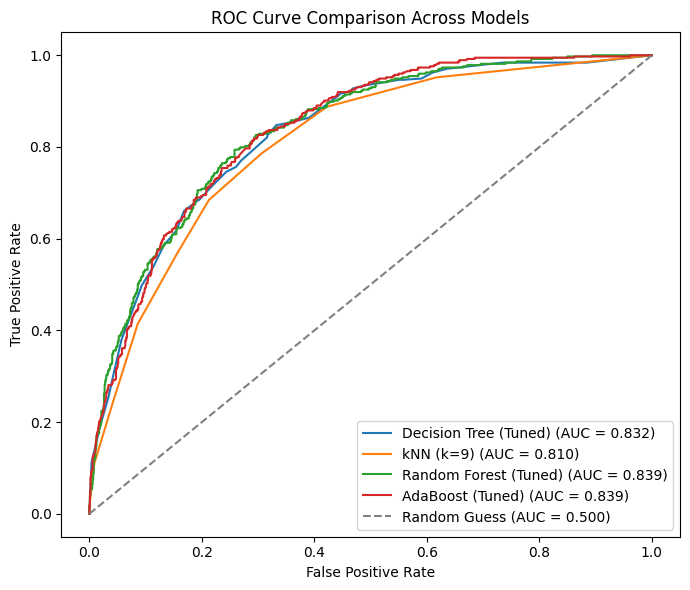

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

# Collect (model, X_test_variant, label) - use scaled test set only for kNN
roc_models = [
    (dt_final,  X_test,        "Decision Tree (Tuned)"),
    (knn_best,  X_test_scaled, f"kNN (k={best_k})"),
    (best_rf,   X_test,        "Random Forest (Tuned)"),
    (best_ada,  X_test,        "AdaBoost (Tuned)"),
]

plt.figure(figsize=(7, 6))

for model, X_eval, label in roc_models:
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.3f})")

# Plot the random-guess reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Guess (AUC = 0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Observations**

- All four models discriminate between churners and non-churners substantially better than random guessing, with every ROC curve lying well above the diagonal reference line (AUC = 0.500) across the full range of classification thresholds.

- **Random Forest (Tuned)** and **AdaBoost (Tuned)** achieve the highest discrimination performance, both with an AUC of 0.839. Decision Tree (Tuned) follows closely at 0.832, while kNN (k=9) records the lowest AUC at 0.810.

- Compared with the accuracy-based results in Section 9.1, the ranking changes slightly. Random Forest remains the strongest overall model, but AdaBoost now matches its AUC despite having a lower classification accuracy. This highlights the difference between accuracy and AUC. Accuracy evaluates performance at a single decision threshold (0.5), whereas AUC measures how well a model separates the two classes across all possible thresholds. AdaBoost's lower accuracy therefore reflects its default decision threshold rather than a weaker ability to distinguish churners from non-churners.

- From a practical perspective, this suggests that AdaBoost could achieve performance comparable to, or potentially better than, Random Forest if the classification threshold were adjusted to suit a specific business objective, such as improving recall in a customer retention campaign.

- The consistently lower AUC of kNN (0.810) aligns with its lower accuracy observed in Section 9.1, reinforcing the conclusion that its distance-based decision rule is less effective at separating churners from non-churners than the tree-based and ensemble models.

---
Note: The Rule-Based classifier is not shown separately because it reproduces the predictions of the Tuned Decision Tree exactly (Section 6.3). Consequently, both models have identical ROC curves and the same AUC of 0.832.

### 9.2 Which Model Performed Best, and Why?

Based on the comparison results, the **tuned Random Forest was the best-performing model overall.**

---
- It achieved the highest accuracy (0.803) and precision (0.667) while maintaining a high specificity (0.906), demonstrating the best balance between correctly identifying churning and non-churning customers.

- Although the kNN classifier achieved the highest recall (0.567) and the tuned Decision Tree achieved the highest specificity (0.910), Random Forest provided the strongest overall generalisation performance across the evaluation metrics.

**The superior performance of Random Forest, explained using the bias-variance trade-off:**

- The baseline Decision Tree exhibited high variance, resulting in overfitting to the training data. Hyperparameter tuning reduced this variance by limiting tree complexity, improving the model's ability to generalise.

- Random Forest further reduced variance by combining predictions from multiple Decision Trees trained on different bootstrap samples and random subsets of features. This ensemble approach produced more stable predictions and reduced the risk of overfitting.

- The AdaBoost classifier also improved predictive performance by sequentially focusing on previously misclassified observations, thereby reducing model bias. However, on this dataset its overall accuracy (0.793) remained slightly below that of the tuned Random Forest.

- Interestingly, **the comparison changes slightly when model performance is evaluated using AUC rather than accuracy**. While Random Forest achieved the highest classification accuracy (Section 9.1), both Random Forest and AdaBoost obtain an identical AUC of 0.839. This indicates that AdaBoost is just as effective as Random Forest at ranking churners ahead of non-churners across all decision thresholds. The difference in their accuracy therefore reflects the choice of the default 0.5 classification threshold rather than a meaningful difference in their underlying discriminative ability. In practice, this means that if the decision threshold were adjusted, for example to prioritise recall in a customer retention campaign, AdaBoost could potentially achieve performance comparable to Random Forest.

- The kNN classifier produced competitive results but was more sensitive to the high-dimensional feature space created after categorical encoding. As the number of features increases, the distances between observations become less informative, making it more difficult for kNN to distinguish between neighbouring customers. This effect, commonly known as the curse of dimensionality, likely contributed to its lower overall accuracy despite achieving the highest recall.

---
Overall, the results demonstrate that ensemble learning, particularly the tuned Random Forest, provides the most effective balance between predictive performance and generalisation for the telecom customer churn prediction task.

### 9.3 Which Model is Most Interpretable, and Why Does That Matter Here?

The **tree-derived rule set** is the most interpretable model in this study, followed closely by the tuned **Decision Tree**.

Each prediction can be traced to a short, human-readable IF-THEN rule or decision path, which makes the model's logic transparent and easy to explain. Unlike ensemble methods such as Random Forest and AdaBoost, the decision process is not hidden inside many combined learners.

---
This matters for a customer churn prediction problem because the model output is meant to support retention actions.

- A customer-success or retention team needs to understand why a customer has been flagged, for example, because of a month-to-month contract, low tenure, or fibre optic service.

- That explanation helps the team choose a targeted intervention, such as a discount, a contract upgrade, or a service-specific retention offer.

- An opaque score alone is less useful because it does not tell the business what factor is driving churn risk or how to respond.

---
In this context, interpretability is not just a convenience. It is a practical requirement for trust, actionability and stakeholder acceptance. Even if an ensemble model performs slightly better overall, the tuned Decision Tree and extracted rule set remain valuable because they provide a clear explanation for each prediction.

### 9.4 Real-World Risks / Failure Modes if Deployed

Deploying a customer churn prediction model in a real-world environment involves several practical risks that should be considered alongside predictive performance.

- A **false negative**, where a customer who is likely to churn is predicted as No Churn, is typically the most costly error. In this case, the retention team does not intervene, resulting in the loss of the customer and their future revenue. For businesses with high customer lifetime value, such missed opportunities can have a significant financial impact.

- A **false positive** occurs when a loyal customer is incorrectly predicted to churn. Although less severe than a false negative, it can lead to unnecessary retention incentives, increased operational costs, and inefficient use of marketing resources.

- Another important challenge is **data drift**. Customer behaviour, pricing strategies, service offerings and competitive market conditions evolve over time. As these underlying patterns change, the model's predictive performance may deteriorate. Continuous monitoring and periodic retraining are therefore essential to maintain reliable performance.

- Finally, **fairness and ethical considerations** should be addressed before deployment. Features such as gender and SeniorCitizen, or variables correlated with them, may unintentionally introduce demographic bias into model predictions. Evaluating model performance across different customer groups helps ensure that retention strategies remain fair and equitable.

---
Overall, the tuned Random Forest model is well suited for prioritising customer retention efforts. However, successful deployment requires continuous performance monitoring, periodic model retraining, and regular fairness assessments to ensure reliable and responsible decision-making.

## 10. Reproducibility & Documentation

### 10.1 Random Seed & Reproducibility

Machine learning workflows involve stochastic processes such as train-test splitting, cross-validation, and the training of ensemble models. To ensure reproducibility, a single fixed random seed was used consistently throughout this notebook.

In [46]:
print(f"Random state used throughout this notebook: {RANDOM_STATE}")

Random state used throughout this notebook: 42


The value RANDOM_STATE = 42 was applied to the train-test split, the StratifiedKFold cross-validation procedure, and all models supporting the random_state parameter, including the Decision Tree, Random Forest, and AdaBoost classifiers. Using a fixed random seed ensures that the dataset partitioning, cross-validation folds, and model training remain consistent, allowing the entire analysis to be reproduced with identical results.

### 10.2 Libraries & Environment

The Python version, operating system, and key library versions used in this notebook are recorded below. Documenting the computational environment helps ensure reproducibility and simplifies troubleshooting if results differ across systems or library versions.

In [47]:
# Import libraries required for environment reporting
import sys
import platform
import sklearn

# Create environment summary
environment = pd.DataFrame({
    "Component": [
        "Python",
        "Operating System",
        "Pandas",
        "NumPy",
        "Matplotlib",
        "Seaborn",
        "Scikit-learn"
    ],
    "Version": [
        sys.version.split()[0],
        platform.platform(),
        pd.__version__,
        np.__version__,
        plt.matplotlib.__version__,
        sns.__version__,
        sklearn.__version__
    ]
})

# Display environment information
environment.style.hide(axis="index").set_caption(
    "Software Environment Used for the Analysis")

Component,Version
Python,3.12.13
Operating System,Linux-6.6.122+-x86_64-with-glibc2.35
Pandas,2.2.2
NumPy,2.0.2
Matplotlib,3.10.0
Seaborn,0.13.2
Scikit-learn,1.6.1


### 10.3 Project Workflow Summary

The project followed a structured machine learning workflow, beginning with data understanding and preparation, followed by the development, tuning, and evaluation of multiple classification models. The final recommendation was based on quantitative performance metrics together with considerations of model generalisation and interpretability.

In [52]:
workflow_summary = pd.DataFrame({
    "Stage": [
        "Data Understanding & Audit",
        "Data Preparation",
        "Decision Tree",
        "Rule-Based Classification",
        "k-Nearest Neighbours (kNN)",
        "Ensemble Learning",
        "Model Comparison & Recommendation"
    ],
    "Description": [
        "Explored the dataset, examined data types, identified missing values and analysed the target distribution.",
        "Cleaned data, handled missing values, encoded categorical variables, scaled numerical features where required and prepared leakage-free training and testing datasets.",
        "Developed a baseline Decision Tree, diagnosed overfitting, performed hyperparameter tuning using cross-validation and interpreted the final model.",
        "Extracted human-readable IF-THEN rules from the tuned Decision Tree and evaluated their predictive performance.",
        "Compared multiple values of k, selected the optimal model using cross-validation, and analysed the impact of feature scaling.",
        "Developed and tuned Random Forest and AdaBoost classifiers and compared bagging and boosting approaches.",
        "Compared all models using multiple evaluation metrics and selected the final model based on predictive performance, generalisation and interpretability."
    ]
})

workflow_summary.style.hide(axis="index").set_caption("Summary of End-to-End Machine Learning Workflow")

Stage,Description
Data Understanding & Audit,"Explored the dataset, examined data types, identified missing values and analysed the target distribution."
Data Preparation,"Cleaned data, handled missing values, encoded categorical variables, scaled numerical features where required and prepared leakage-free training and testing datasets."
Decision Tree,"Developed a baseline Decision Tree, diagnosed overfitting, performed hyperparameter tuning using cross-validation and interpreted the final model."
Rule-Based Classification,Extracted human-readable IF-THEN rules from the tuned Decision Tree and evaluated their predictive performance.
k-Nearest Neighbours (kNN),"Compared multiple values of k, selected the optimal model using cross-validation, and analysed the impact of feature scaling."
Ensemble Learning,Developed and tuned Random Forest and AdaBoost classifiers and compared bagging and boosting approaches.
Model Comparison & Recommendation,"Compared all models using multiple evaluation metrics and selected the final model based on predictive performance, generalisation and interpretability."


## 11. Conclusion

An end-to-end supervised learning pipeline was developed for Telco customer churn prediction, beginning with data understanding and leakage-free preprocessing and extending through the training, tuning and comparison of multiple model families:

- a Decision Tree
- a rule-based classifier derived from Decision Tree
- k-Nearest Neighbours
- Random Forest
- AdaBoost

A key design choice throughout the analysis was to select hyperparameters using cross-validation on the training set only, while reserving the test set for a single final evaluation. This ensured that the reported test metrics provide an unbiased estimate of generalisation performance. Among the models evaluated, the ensemble methods delivered the strongest predictive results, which is consistent with the bias-variance trade-off: bagging and boosting both improve generalisation relative to a single Decision Tree, but through different mechanisms.

At the same time, the tuned Decision Tree and its extracted rule set remain the most interpretable choices, which matters in a churn-management setting where retention teams need clear, actionable explanations for why a customer has been flagged.

---
Overall, there is no single universally best model. The final choice depends on the business objective.

- If the priority is **maximum predictive performance**, the **tuned Random Forest** is the strongest candidate.

- If the **priority is transparency and actionability**, the **tuned Decision Tree** or its rule-based representation is the more defensible option.


## 12. References

**Dataset**

1. Blastchar. *Telco Customer Churn Dataset*. Kaggle.  
   https://www.kaggle.com/datasets/blastchar/telco-customer-churn

---

**Software Libraries**

2. Scikit-learn Developers. *Scikit-learn: Machine Learning in Python - User Guide*.  
   https://scikit-learn.org/stable/user_guide.html

3. Pandas Development Team. *Pandas User Guide*.  
   https://pandas.pydata.org/docs/user_guide/index.html

4. NumPy Developers. *NumPy User Guide*.  
   https://numpy.org/doc/stable/user/index.html

5. Matplotlib Development Team. *Matplotlib User Guide*.  
   https://matplotlib.org/stable/users/index.html

6. Seaborn Development Team. *Seaborn Tutorial*.  
   https://seaborn.pydata.org/tutorial.html

---

**Reference Text**

7. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3rd ed.). O'Reilly Media.